In [1]:
# ============================================================
# MGT-353 Supply Chain Analytics
# Portfolio Milestone 1
# Engro Fertilizers Limited (EFERT) - Engro Urea
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
file_name = "MGT353_Forecasting_M1_EFERT_Synthetic_Dataset.xlsx"

df = pd.read_excel(
    file_name,
    sheet_name="Synthetic_Data",
    header=2
)

df["Week_Start_Date"] = pd.to_datetime(df["Week_Start_Date"])

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (156, 14)


,Week_Start_Date,Product_or_Category,Actual_Demand_Bags,Demand_Tonnes,Historical_Forecast,Price_PKR_Per_Bag,Promo_Flag,Promo_Depth_Pct,Event_Flag,Agricultural_Season,Distribution_Points,Stockout_Flag,Exceptional_Event,Dataset_Split
0,2023-01-02,Engro Urea - 50 kg bag,893000,44650,892000,3450,0,0.0,1,Rabi demand window,978,0,NaN,Train
1,2023-01-09,Engro Urea - 50 kg bag,900000,45000,900000,3490,0,0.0,1,Rabi demand window,967,0,NaN,Train
2,2023-01-16,Engro Urea - 50 kg bag,899000,44950,949000,3470,0,0.0,1,Rabi demand window,939,0,NaN,Train
3,2023-01-23,Engro Urea - 50 kg bag,878000,43900,949000,3490,0,0.0,1,Rabi demand window,968,0,NaN,Train
4,2023-01-30,Engro Urea - 50 kg bag,906000,45300,936000,3410,0,0.0,1,Rabi demand window,955,0,NaN,Train


In [3]:
print("Date range:")
print(df["Week_Start_Date"].min(), "to", df["Week_Start_Date"].max())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDataset split:")
print(df["Dataset_Split"].value_counts())

print("\nPromotion frequency:")
print(df["Promo_Flag"].value_counts(normalize=True))

print("\nStockout frequency:")
print(df["Stockout_Flag"].value_counts())

print("\nUnique prices:")
print(df["Price_PKR_Per_Bag"].nunique())

Date range:
2023-01-02 00:00:00 to 2025-12-22 00:00:00

Missing values:
Week_Start_Date          0
Product_or_Category      0
Actual_Demand_Bags       0
Demand_Tonnes            0
Historical_Forecast      0
Price_PKR_Per_Bag        0
Promo_Flag               0
Promo_Depth_Pct          0
Event_Flag               0
Agricultural_Season      0
Distribution_Points      0
Stockout_Flag            0
Exceptional_Event      150
Dataset_Split            0
dtype: int64

Dataset split:
Dataset_Split
Train      144
Holdout     12
Name: count, dtype: int64

Promotion frequency:
Promo_Flag
0    0.833333
1    0.166667
Name: proportion, dtype: float64

Stockout frequency:
Stockout_Flag
0    150
1      6
Name: count, dtype: int64

Unique prices:
32


In [5]:
print(f"Mean: {mean_demand:,.0f} bags/week")
print(f"Median: {median_demand:,.0f} bags/week")
print(f"Standard Deviation: {std_demand:,.0f} bags")
print(f"Minimum: {minimum_demand:,.0f} bags")
print(f"Maximum: {maximum_demand:,.0f} bags")
print(f"Range: {demand_range:,.0f} bags")
print(f"Coefficient of Variation: {cv:.2%}")

Mean: 882,462 bags/week
Median: 866,000 bags/week
Standard Deviation: 151,633 bags
Minimum: 450,000 bags
Maximum: 1,227,000 bags
Range: 777,000 bags
Coefficient of Variation: 17.18%


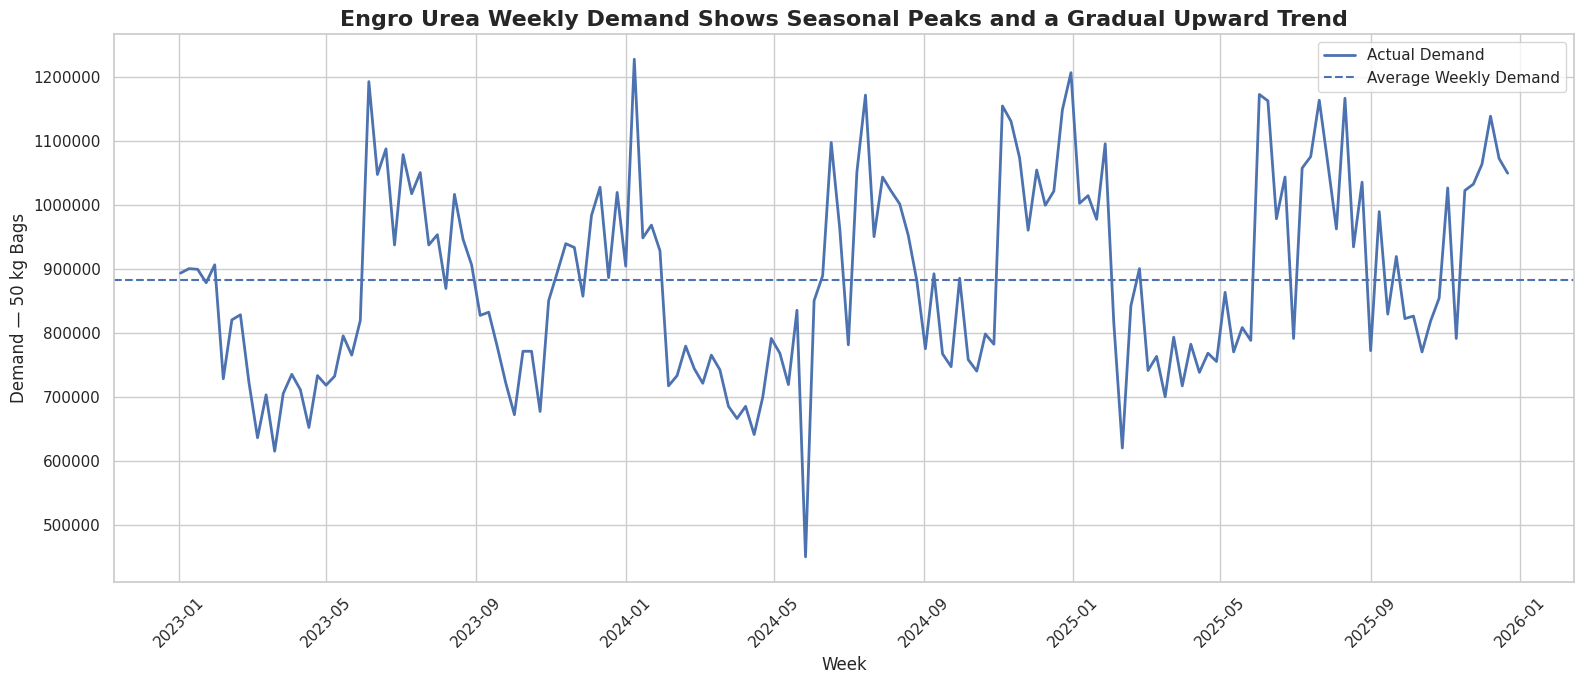

In [6]:
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(
    df["Week_Start_Date"],
    df["Actual_Demand_Bags"],
    linewidth=2,
    label="Actual Demand"
)

ax.axhline(
    df["Actual_Demand_Bags"].mean(),
    linestyle="--",
    linewidth=1.5,
    label="Average Weekly Demand"
)

ax.set_title(
    "Engro Urea Weekly Demand Shows Seasonal Peaks and a Gradual Upward Trend",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Week")
ax.set_ylabel("Demand — 50 kg Bags")

ax.ticklabel_format(
    style="plain",
    axis="y"
)

ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

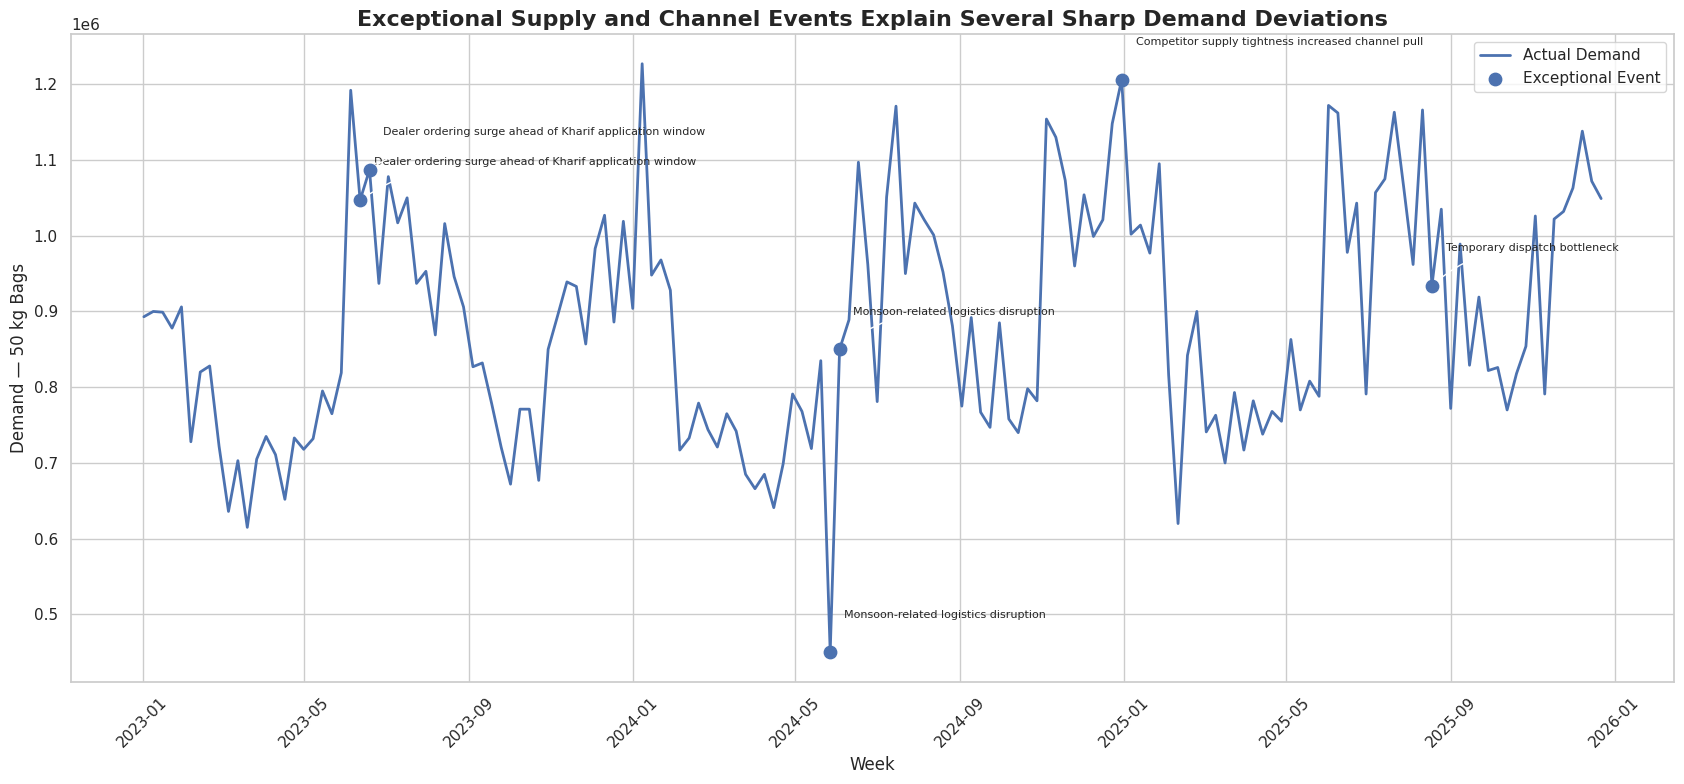

In [7]:
event_df = df[df["Exceptional_Event"].notna()].copy()

fig, ax = plt.subplots(figsize=(17, 8))

ax.plot(
    df["Week_Start_Date"],
    df["Actual_Demand_Bags"],
    linewidth=2,
    label="Actual Demand"
)

ax.scatter(
    event_df["Week_Start_Date"],
    event_df["Actual_Demand_Bags"],
    s=80,
    zorder=5,
    label="Exceptional Event"
)

for _, row in event_df.iterrows():
    ax.annotate(
        row["Exceptional_Event"],
        xy=(row["Week_Start_Date"], row["Actual_Demand_Bags"]),
        xytext=(10, 25),
        textcoords="offset points",
        fontsize=8,
        arrowprops=dict(
            arrowstyle="->",
            connectionstyle="arc3,rad=0.2"
        )
    )

ax.set_title(
    "Exceptional Supply and Channel Events Explain Several Sharp Demand Deviations",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Week")
ax.set_ylabel("Demand — 50 kg Bags")

ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
df["Year"] = df["Week_Start_Date"].dt.year

annual_summary = (
    df.groupby("Year")["Actual_Demand_Bags"]
      .agg(["mean", "sum", "min", "max"])
)

annual_summary

,mean,sum,min,max
Year,,,,
2023,853173.076923,44365000,615000,1192000
2024,880245.283019,46653000,450000,1227000
2025,914627.450980,46646000,620000,1172000


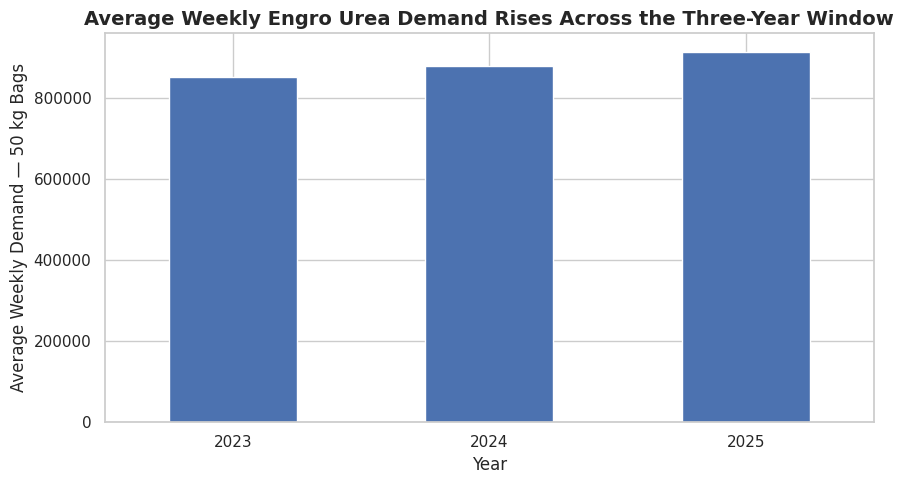

In [10]:
annual_mean = (
    df.groupby("Year")["Actual_Demand_Bags"]
      .mean()
)

plt.figure(figsize=(9, 5))

annual_mean.plot(
    kind="bar"
)

plt.title(
    "Average Weekly Engro Urea Demand Rises Across the Three-Year Window",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Average Weekly Demand — 50 kg Bags")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
season_summary = (
    df.groupby("Agricultural_Season")["Actual_Demand_Bags"]
      .agg(["mean", "median", "std", "count"])
      .sort_values("mean", ascending=False)
)

season_summary

,mean,median,std,count
Agricultural_Season,,,,
Kharif demand window,959264.150943,953000.0,126206.355890,53
Rabi demand window,946352.941176,948000.0,136103.317157,51
Normal / shoulder period,741519.230769,748500.0,70794.785004,52


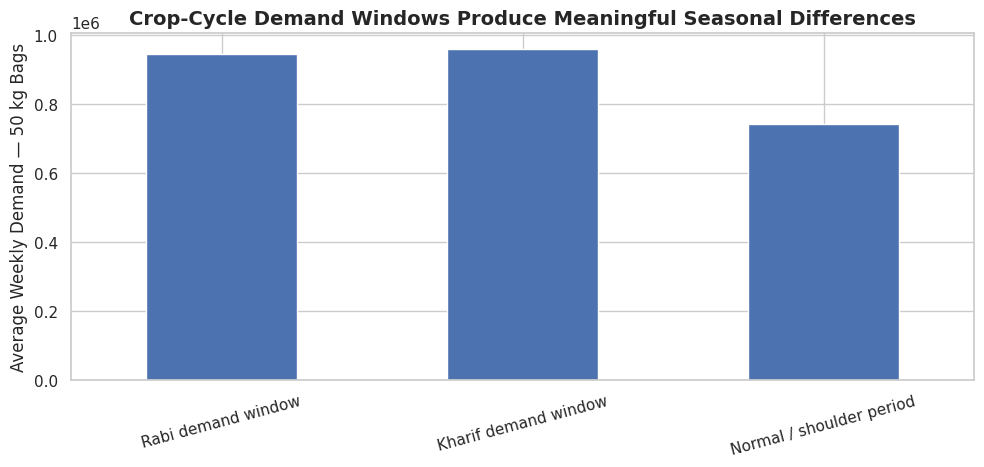

In [12]:
season_order = [
    "Rabi demand window",
    "Kharif demand window",
    "Normal / shoulder period"
]

season_mean = (
    df.groupby("Agricultural_Season")["Actual_Demand_Bags"]
      .mean()
      .reindex(season_order)
)

plt.figure(figsize=(10, 5))

season_mean.plot(kind="bar")

plt.title(
    "Crop-Cycle Demand Windows Produce Meaningful Seasonal Differences",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Average Weekly Demand — 50 kg Bags")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [13]:
promo_summary = (
    df.groupby("Promo_Flag")["Actual_Demand_Bags"]
      .agg(["mean", "median", "std", "count"])
)

promo_summary.index = ["No Promotion", "Promotion"]
promo_summary

,mean,median,std,count
No Promotion,8.549615e+05,827500.0,137630.524594,130
Promotion,1.019962e+06,1075500.0,145662.481311,26


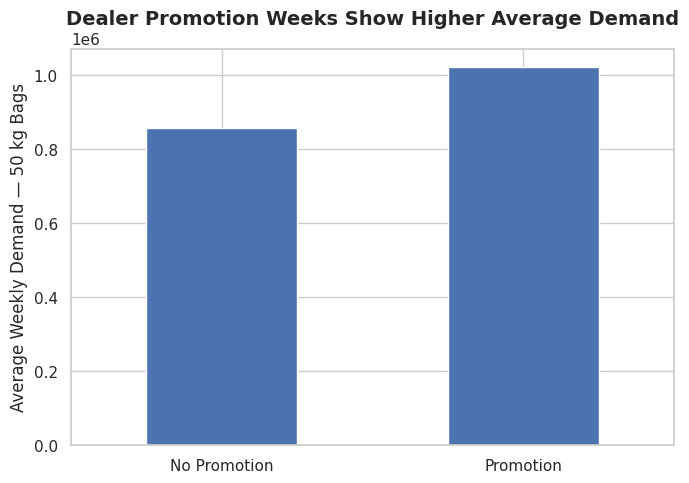

In [14]:
promo_means = (
    df.groupby("Promo_Flag")["Actual_Demand_Bags"]
      .mean()
)

plt.figure(figsize=(7,5))

promo_means.plot(kind="bar")

plt.title(
    "Dealer Promotion Weeks Show Higher Average Demand",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Average Weekly Demand — 50 kg Bags")
plt.xticks([0,1], ["No Promotion", "Promotion"], rotation=0)
plt.tight_layout()
plt.show()

### Demand Pattern Diagnosis:
The synthetic Engro Urea demand series shows a relatively high and stable underlying weekly level, combined with a gradual upward trend and meaningful agricultural seasonality. Average demand increases across the three-year period, while recurring Rabi and Kharif application windows create identifiable demand peaks relative to shoulder periods. Weekly variability remains material, with a coefficient of variation of approximately 17.2%, indicating that demand is neither completely stable nor excessively erratic. Promotional activity, stock availability and several exceptional channel or logistics events create additional short-term deviations from the underlying pattern. The presence of both trend and recurring seasonal structure means that level-only techniques such as simple moving averages or simple exponential smoothing may lag during turning points. Therefore, the forecasting comparison should include simple baselines alongside trend- and season-capable approaches such as Seasonal Naive and Holt-Winters.

In [15]:
# ============================================================
# STAGE 4 — FORECAST ERROR FUNDAMENTALS
# Error convention: Actual - Forecast
# ============================================================

error_df = df.copy()

error_df["Error"] = (
    error_df["Actual_Demand_Bags"]
    - error_df["Historical_Forecast"]
)

error_df["Absolute_Error"] = error_df["Error"].abs()

error_df["Absolute_Percentage_Error"] = (
    error_df["Absolute_Error"]
    / error_df["Actual_Demand_Bags"]
)

error_df["Squared_Error"] = (
    error_df["Error"] ** 2
)

error_df["Cumulative_Error_RSFE"] = (
    error_df["Error"].cumsum()
)

error_df[
    [
        "Week_Start_Date",
        "Actual_Demand_Bags",
        "Historical_Forecast",
        "Error",
        "Absolute_Error",
        "Absolute_Percentage_Error",
        "Cumulative_Error_RSFE"
    ]
].head(10)

,Week_Start_Date,Actual_Demand_Bags,Historical_Forecast,Error,Absolute_Error,Absolute_Percentage_Error,Cumulative_Error_RSFE
0,2023-01-02,893000,892000,1000,1000,0.001120,1000
1,2023-01-09,900000,900000,0,0,0.000000,1000
2,2023-01-16,899000,949000,-50000,50000,0.055617,-49000
3,2023-01-23,878000,949000,-71000,71000,0.080866,-120000
4,2023-01-30,906000,936000,-30000,30000,0.033113,-150000
5,2023-02-06,728000,879000,-151000,151000,0.207418,-301000
6,2023-02-13,820000,718000,102000,102000,0.124390,-199000
7,2023-02-20,828000,798000,30000,30000,0.036232,-169000
8,2023-02-27,722000,812000,-90000,90000,0.124654,-259000
9,2023-03-06,636000,709000,-73000,73000,0.114780,-332000


In [16]:
# Number of observations
n = len(error_df)

# Mean Absolute Deviation / Mean Absolute Error
MAD = error_df["Absolute_Error"].mean()

# Mean Absolute Percentage Error
MAPE = error_df["Absolute_Percentage_Error"].mean() * 100

# Root Mean Squared Error
RMSE = np.sqrt(error_df["Squared_Error"].mean())

# Weighted Absolute Percentage Error
WAPE = (
    error_df["Absolute_Error"].sum()
    / error_df["Actual_Demand_Bags"].sum()
) * 100

# Bias / Mean Forecast Error
Bias = error_df["Error"].mean()

# Running Sum of Forecast Errors
RSFE = error_df["Error"].sum()

# Tracking Signal
Tracking_Signal = RSFE / MAD

metrics = pd.DataFrame({
    "Metric": [
        "MAD / MAE",
        "MAPE",
        "RMSE",
        "WAPE",
        "Bias / MFE",
        "RSFE",
        "Tracking Signal"
    ],
    "Value": [
        MAD,
        MAPE,
        RMSE,
        WAPE,
        Bias,
        RSFE,
        Tracking_Signal
    ]
})

metrics

,Metric,Value
0,MAD / MAE,1.006923e+05
1,MAPE,1.153420e+01
2,RMSE,1.338290e+05
3,WAPE,1.141039e+01
4,Bias / MFE,-6.435897e+03
5,RSFE,-1.004000e+06
6,Tracking Signal,-9.970970e+00


In [17]:
print(f"MAD / MAE: {MAD:,.0f} bags")
print(f"MAPE: {MAPE:.2f}%")
print(f"RMSE: {RMSE:,.0f} bags")
print(f"WAPE: {WAPE:.2f}%")
print(f"Bias / MFE: {Bias:,.0f} bags")
print(f"RSFE: {RSFE:,.0f} bags")
print(f"Tracking Signal: {Tracking_Signal:.2f}")

MAD / MAE: 100,692 bags
MAPE: 11.53%
RMSE: 133,829 bags
WAPE: 11.41%
Bias / MFE: -6,436 bags
RSFE: -1,004,000 bags
Tracking Signal: -9.97


In [18]:
interpretations = {
    "MAD / MAE":
        f"The historical forecast is typically off by about {MAD:,.0f} bags per week.",

    "MAPE":
        f"On average, the forecast misses actual weekly demand by approximately {MAPE:.1f}% in percentage terms.",

    "RMSE":
        f"The RMSE of {RMSE:,.0f} bags is higher than MAD because large weekly forecast misses receive more weight.",

    "WAPE":
        f"Total absolute forecast error is approximately {WAPE:.1f}% of total observed demand volume.",

    "Bias / MFE":
        (
            f"The average signed error is {Bias:,.0f} bags. "
            + (
                "Because Error = Actual - Forecast, the positive sign indicates systematic under-forecasting."
                if Bias > 0
                else "Because Error = Actual - Forecast, the negative sign indicates systematic over-forecasting."
                if Bias < 0
                else "The average signed error is approximately zero, indicating little overall directional bias."
            )
        ),

    "RSFE":
        f"The cumulative signed forecast error across the full series is {RSFE:,.0f} bags.",

    "Tracking Signal":
        (
            f"The Tracking Signal is {Tracking_Signal:.2f}. "
            "Its sign shows the direction of accumulated forecast bias relative to normal absolute error."
        )
}

for metric, text in interpretations.items():
    print(f"\n{metric}")
    print(text)


MAD / MAE
The historical forecast is typically off by about 100,692 bags per week.

MAPE
On average, the forecast misses actual weekly demand by approximately 11.5% in percentage terms.

RMSE
The RMSE of 133,829 bags is higher than MAD because large weekly forecast misses receive more weight.

WAPE
Total absolute forecast error is approximately 11.4% of total observed demand volume.

Bias / MFE
The average signed error is -6,436 bags. Because Error = Actual - Forecast, the negative sign indicates systematic over-forecasting.

RSFE
The cumulative signed forecast error across the full series is -1,004,000 bags.

Tracking Signal
The Tracking Signal is -9.97. Its sign shows the direction of accumulated forecast bias relative to normal absolute error.


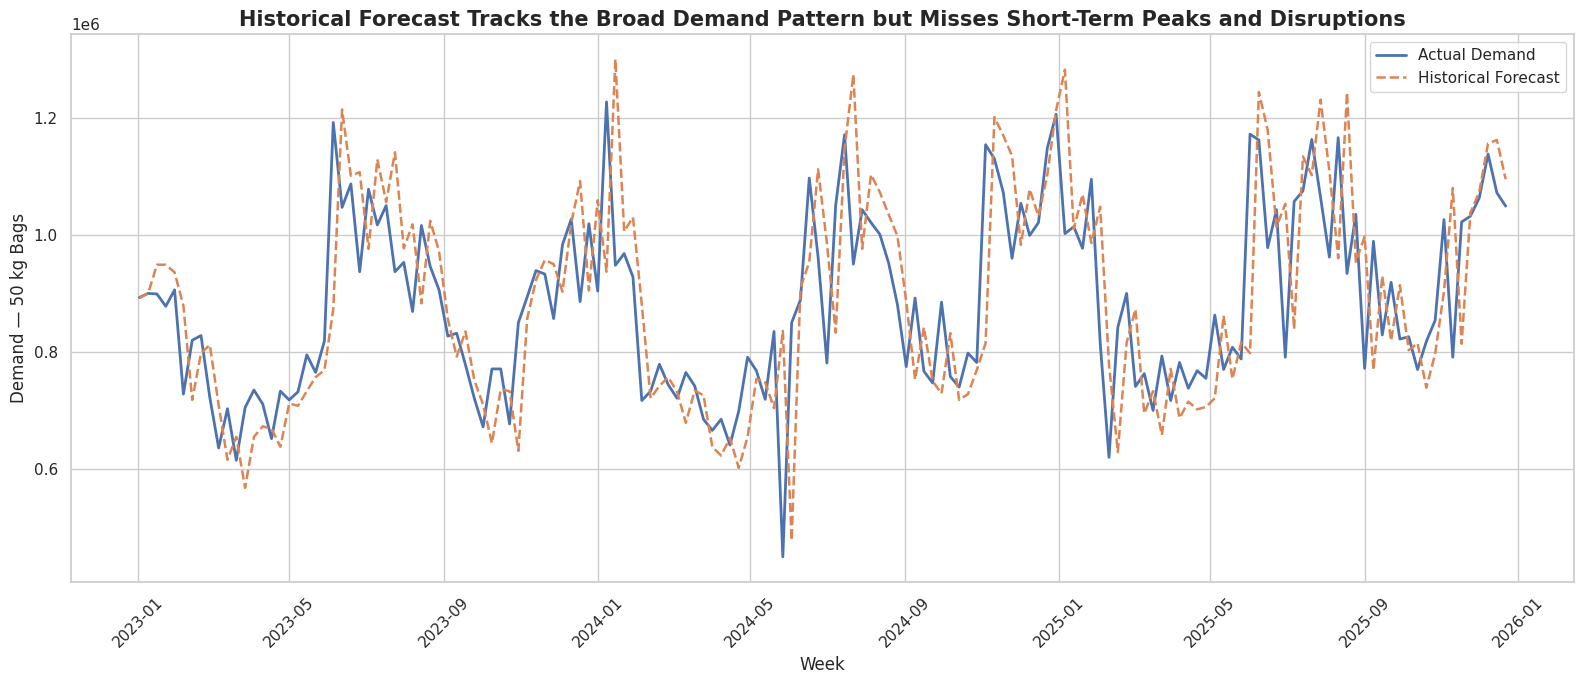

In [19]:
plt.figure(figsize=(16, 7))

plt.plot(
    error_df["Week_Start_Date"],
    error_df["Actual_Demand_Bags"],
    linewidth=2,
    label="Actual Demand"
)

plt.plot(
    error_df["Week_Start_Date"],
    error_df["Historical_Forecast"],
    linewidth=1.8,
    linestyle="--",
    label="Historical Forecast"
)

plt.title(
    "Historical Forecast Tracks the Broad Demand Pattern but Misses Short-Term Peaks and Disruptions",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Week")
plt.ylabel("Demand — 50 kg Bags")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

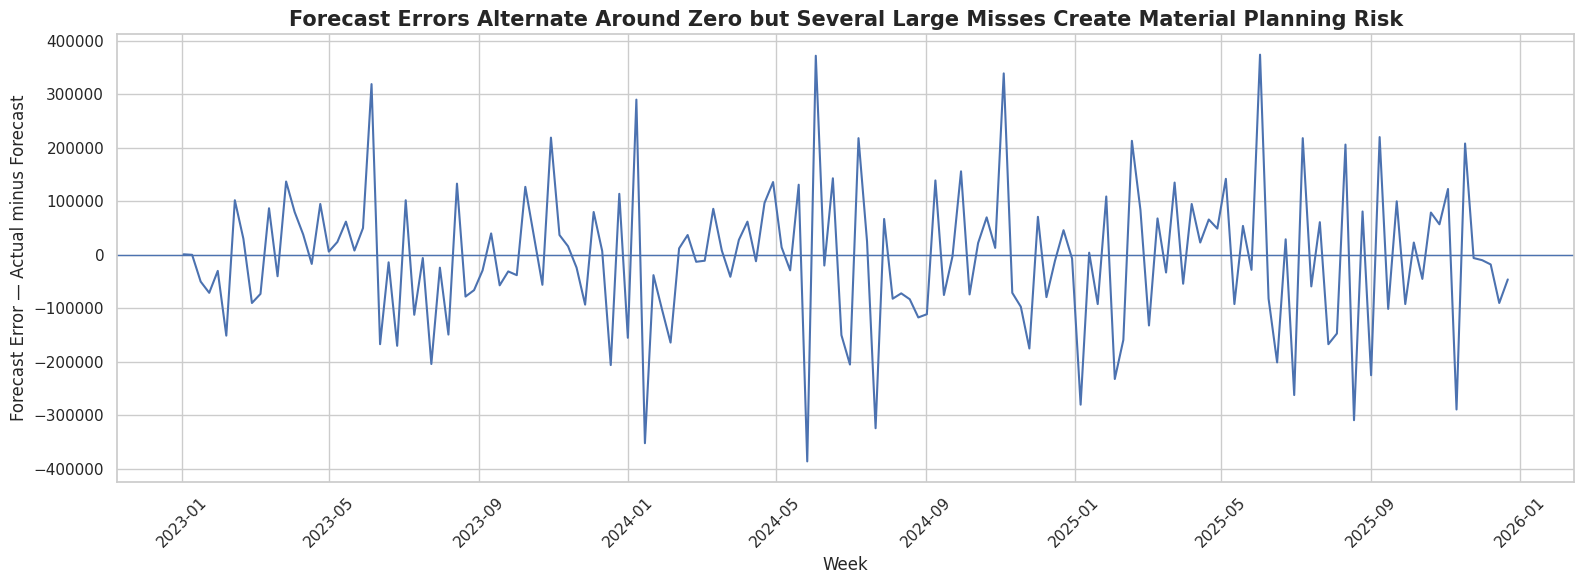

In [20]:
plt.figure(figsize=(16, 6))

plt.axhline(
    y=0,
    linewidth=1
)

plt.plot(
    error_df["Week_Start_Date"],
    error_df["Error"],
    linewidth=1.5
)

plt.title(
    "Forecast Errors Alternate Around Zero but Several Large Misses Create Material Planning Risk",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Week")
plt.ylabel("Forecast Error — Actual minus Forecast")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
largest_misses = (
    error_df
    .sort_values("Absolute_Error", ascending=False)
    [
        [
            "Week_Start_Date",
            "Actual_Demand_Bags",
            "Historical_Forecast",
            "Error",
            "Absolute_Error",
            "Promo_Flag",
            "Event_Flag",
            "Stockout_Flag",
            "Exceptional_Event"
        ]
    ]
    .head(10)
)

largest_misses

,Week_Start_Date,Actual_Demand_Bags,Historical_Forecast,Error,Absolute_Error,Promo_Flag,Event_Flag,Stockout_Flag,Exceptional_Event
73,2024-05-27,450000,836000,-386000,386000,0,0,1,Monsoon-related logistics disruption
126,2025-06-02,1172000,798000,374000,374000,1,1,0,NaN
74,2024-06-03,850000,478000,372000,372000,0,1,0,Monsoon-related logistics disruption
54,2024-01-15,948000,1300000,-352000,352000,0,1,0,NaN
96,2024-11-04,1154000,815000,339000,339000,1,1,0,NaN
81,2024-07-22,950000,1274000,-324000,324000,0,1,0,NaN
22,2023-06-05,1192000,873000,319000,319000,1,1,0,NaN
137,2025-08-18,934000,1243000,-309000,309000,0,1,0,Temporary dispatch bottleneck
53,2024-01-08,1227000,937000,290000,290000,1,1,0,NaN
149,2025-11-10,791000,1080000,-289000,289000,0,1,1,NaN


In [22]:
# Promotion vs non-promotion error
promo_error = (
    error_df
    .groupby("Promo_Flag")["Absolute_Error"]
    .mean()
)

promo_error.index = ["No Promotion", "Promotion"]

print("Mean absolute error by promotion status:")
print(promo_error)

print("\nMean absolute error by event status:")
print(
    error_df.groupby("Event_Flag")["Absolute_Error"].mean()
)

print("\nMean absolute error by stockout status:")
print(
    error_df.groupby("Stockout_Flag")["Absolute_Error"].mean()
)

Mean absolute error by promotion status:
No Promotion     92738.461538
Promotion       140461.538462
Name: Absolute_Error, dtype: float64

Mean absolute error by event status:
Event_Flag
0     80166.666667
1    121217.948718
Name: Absolute_Error, dtype: float64

Mean absolute error by stockout status:
Stockout_Flag
0     95266.666667
1    236333.333333
Name: Absolute_Error, dtype: float64


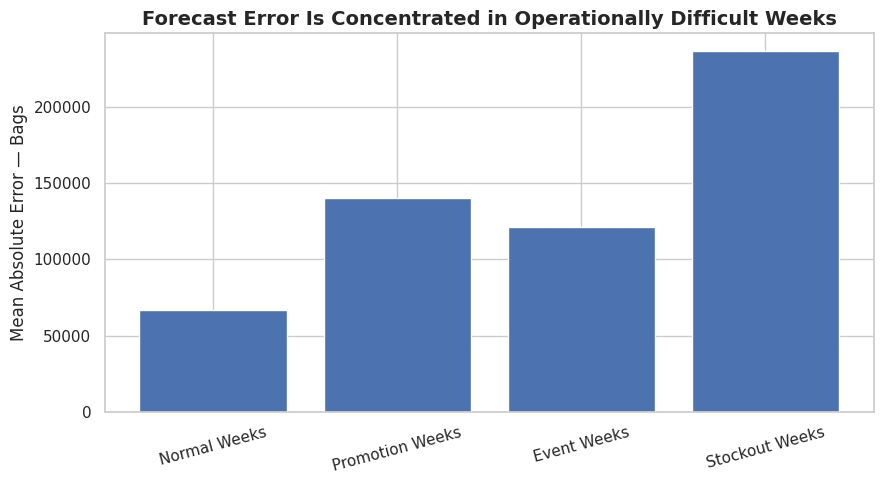

,Condition,Mean Absolute Error
0,Normal Weeks,67123.076923
1,Promotion Weeks,140461.538462
2,Event Weeks,121217.948718
3,Stockout Weeks,236333.333333


In [23]:
condition_summary = pd.DataFrame({
    "Condition": [
        "Normal Weeks",
        "Promotion Weeks",
        "Event Weeks",
        "Stockout Weeks"
    ],
    "Mean Absolute Error": [
        error_df.loc[
            (error_df["Promo_Flag"] == 0)
            & (error_df["Event_Flag"] == 0)
            & (error_df["Stockout_Flag"] == 0),
            "Absolute_Error"
        ].mean(),

        error_df.loc[
            error_df["Promo_Flag"] == 1,
            "Absolute_Error"
        ].mean(),

        error_df.loc[
            error_df["Event_Flag"] == 1,
            "Absolute_Error"
        ].mean(),

        error_df.loc[
            error_df["Stockout_Flag"] == 1,
            "Absolute_Error"
        ].mean()
    ]
})

plt.figure(figsize=(9, 5))

plt.bar(
    condition_summary["Condition"],
    condition_summary["Mean Absolute Error"]
)

plt.title(
    "Forecast Error Is Concentrated in Operationally Difficult Weeks",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Mean Absolute Error — Bags")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

condition_summary

### Forecast Error Diagnosis:
The historical forecast provides a reasonable broad approximation of Engro Urea demand but exhibits material weekly error and persistent directional bias. MAD is approximately 100,692 bags and MAPE is 11.5%, indicating that the typical forecasting miss is operationally significant for weekly production and distributor replenishment planning. RMSE rises to 133,829 bags, confirming that several unusually large misses contribute disproportionately to forecast risk. WAPE of 11.4% provides a similar volume-weighted view of overall forecast accuracy. Using the required convention of Error = Actual − Forecast, the negative mean error of 6,436 bags indicates mild systematic over-forecasting. More importantly, cumulative RSFE reaches −1.004 million bags and the Tracking Signal is −9.97, suggesting that the accumulated bias is too large relative to normal forecast error to be treated purely as random variation.

In [24]:
# ============================================================
# STAGE 5 — FORECAST MODEL COMPARISON
# Common 12-week unseen holdout
# ============================================================

forecast_df = df.copy().sort_values("Week_Start_Date").reset_index(drop=True)

train_df = forecast_df.iloc[:-12].copy()
test_df = forecast_df.iloc[-12:].copy()

print("Training observations:", len(train_df))
print("Holdout observations:", len(test_df))

print("\nTraining period:")
print(
    train_df["Week_Start_Date"].min(),
    "to",
    train_df["Week_Start_Date"].max()
)

print("\nHoldout period:")
print(
    test_df["Week_Start_Date"].min(),
    "to",
    test_df["Week_Start_Date"].max()
)

Training observations: 144
Holdout observations: 12

Training period:
2023-01-02 00:00:00 to 2025-09-29 00:00:00

Holdout period:
2025-10-06 00:00:00 to 2025-12-22 00:00:00


In [25]:
!pip install statsmodels -q

In [26]:
from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing,
    Holt,
    ExponentialSmoothing
)

from sklearn.metrics import mean_squared_error

In [27]:
def forecast_metrics(actual, forecast):

    actual = np.asarray(actual)
    forecast = np.asarray(forecast)

    error = actual - forecast
    absolute_error = np.abs(error)

    MAD = np.mean(absolute_error)

    MAPE = np.mean(
        absolute_error / actual
    ) * 100

    RMSE = np.sqrt(
        np.mean(error ** 2)
    )

    WAPE = (
        np.sum(absolute_error)
        / np.sum(actual)
    ) * 100

    Bias = np.mean(error)

    RSFE = np.sum(error)

    Tracking_Signal = RSFE / MAD

    return {
        "MAD": MAD,
        "MAPE": MAPE,
        "RMSE": RMSE,
        "WAPE": WAPE,
        "Bias": Bias,
        "RSFE": RSFE,
        "Tracking Signal": Tracking_Signal
    }

In [28]:
last_train_value = train_df["Actual_Demand_Bags"].iloc[-1]

naive_forecast = np.repeat(
    last_train_value,
    len(test_df)
)

naive_forecast

array([822000, 822000, 822000, 822000, 822000, 822000, 822000, 822000,
       822000, 822000, 822000, 822000])

In [29]:
season_length = 52

seasonal_naive_forecast = (
    train_df["Actual_Demand_Bags"]
    .iloc[-season_length:-season_length + len(test_df)]
    .values
)

seasonal_naive_forecast

array([ 758000,  740000,  798000,  782000, 1154000, 1130000, 1073000,
        960000, 1054000,  999000, 1021000, 1148000])

In [30]:
print(len(seasonal_naive_forecast))

12


In [31]:
history = list(
    train_df["Actual_Demand_Bags"].values
)

moving_average_forecast = []

window = 4

for _ in range(len(test_df)):

    next_forecast = np.mean(
        history[-window:]
    )

    moving_average_forecast.append(
        next_forecast
    )

    # Append the forecast, NOT the unseen actual
    history.append(next_forecast)

moving_average_forecast = np.array(
    moving_average_forecast
)

In [32]:
ses_03_model = SimpleExpSmoothing(
    train_df["Actual_Demand_Bags"],
    initialization_method="estimated"
).fit(
    smoothing_level=0.3,
    optimized=False
)

ses_03_forecast = ses_03_model.forecast(
    len(test_df)
).values

In [33]:
ses_06_model = SimpleExpSmoothing(
    train_df["Actual_Demand_Bags"],
    initialization_method="estimated"
).fit(
    smoothing_level=0.6,
    optimized=False
)

ses_06_forecast = ses_06_model.forecast(
    len(test_df)
).values

In [34]:
holt_model = Holt(
    train_df["Actual_Demand_Bags"],
    initialization_method="estimated"
).fit()

holt_forecast = holt_model.forecast(
    len(test_df)
).values

In [35]:
hw_model = ExponentialSmoothing(
    train_df["Actual_Demand_Bags"],
    trend="add",
    seasonal="add",
    seasonal_periods=52,
    initialization_method="estimated"
).fit(
    optimized=True
)

hw_forecast = hw_model.forecast(
    len(test_df)
).values

In [36]:
model_forecasts = {
    "Naive": naive_forecast,
    "Seasonal Naive": seasonal_naive_forecast,
    "Moving Average (4-week)": moving_average_forecast,
    "SES α=0.3": ses_03_forecast,
    "SES α=0.6": ses_06_forecast,
    "Holt Trend": holt_forecast,
    "Holt-Winters": hw_forecast
}

In [37]:
comparison_results = []

actual_holdout = test_df[
    "Actual_Demand_Bags"
].values

for model_name, forecast in model_forecasts.items():

    metrics = forecast_metrics(
        actual_holdout,
        forecast
    )

    metrics["Model"] = model_name

    comparison_results.append(metrics)

model_comparison = pd.DataFrame(
    comparison_results
)

model_comparison = model_comparison[
    [
        "Model",
        "MAD",
        "MAPE",
        "RMSE",
        "WAPE",
        "Bias",
        "RSFE",
        "Tracking Signal"
    ]
]

model_comparison = model_comparison.sort_values(
    "WAPE"
).reset_index(drop=True)

model_comparison

,Model,MAD,MAPE,RMSE,WAPE,Bias,RSFE,Tracking Signal
0,Holt-Winters,63430.532311,7.093536,94007.894982,6.641361,-28192.178403,-3.383061e+05,-5.333490
1,Seasonal Naive,89833.333333,9.796690,123153.698009,9.405811,-13000.000000,-1.560000e+05,-1.736549
2,SES α=0.3,129915.930294,13.242216,140717.302605,13.602575,63078.915099,7.569470e+05,5.826437
3,Moving Average (4-week),134579.381451,13.440307,152458.593581,14.090852,84438.797141,1.013266e+06,7.529129
4,SES α=0.6,136369.119249,13.396463,161594.008333,14.278243,101440.691080,1.217288e+06,8.926422
5,Holt Trend,137550.625851,13.550207,161711.128668,14.401950,99573.059873,1.194877e+06,8.686814
6,Naive,147583.333333,14.216189,183121.771871,15.452404,133083.333333,1.597000e+06,10.821005


In [38]:
display_table = model_comparison.copy()

display_table["MAD"] = (
    display_table["MAD"]
    .round(0)
    .astype(int)
)

display_table["MAPE"] = (
    display_table["MAPE"]
    .round(2)
)

display_table["RMSE"] = (
    display_table["RMSE"]
    .round(0)
    .astype(int)
)

display_table["WAPE"] = (
    display_table["WAPE"]
    .round(2)
)

display_table["Bias"] = (
    display_table["Bias"]
    .round(0)
    .astype(int)
)

display_table["RSFE"] = (
    display_table["RSFE"]
    .round(0)
    .astype(int)
)

display_table["Tracking Signal"] = (
    display_table["Tracking Signal"]
    .round(2)
)

display_table

,Model,MAD,MAPE,RMSE,WAPE,Bias,RSFE,Tracking Signal
0,Holt-Winters,63431,7.09,94008,6.64,-28192,-338306,-5.33
1,Seasonal Naive,89833,9.80,123154,9.41,-13000,-156000,-1.74
2,SES α=0.3,129916,13.24,140717,13.60,63079,756947,5.83
3,Moving Average (4-week),134579,13.44,152459,14.09,84439,1013266,7.53
4,SES α=0.6,136369,13.40,161594,14.28,101441,1217288,8.93
5,Holt Trend,137551,13.55,161711,14.40,99573,1194877,8.69
6,Naive,147583,14.22,183122,15.45,133083,1597000,10.82


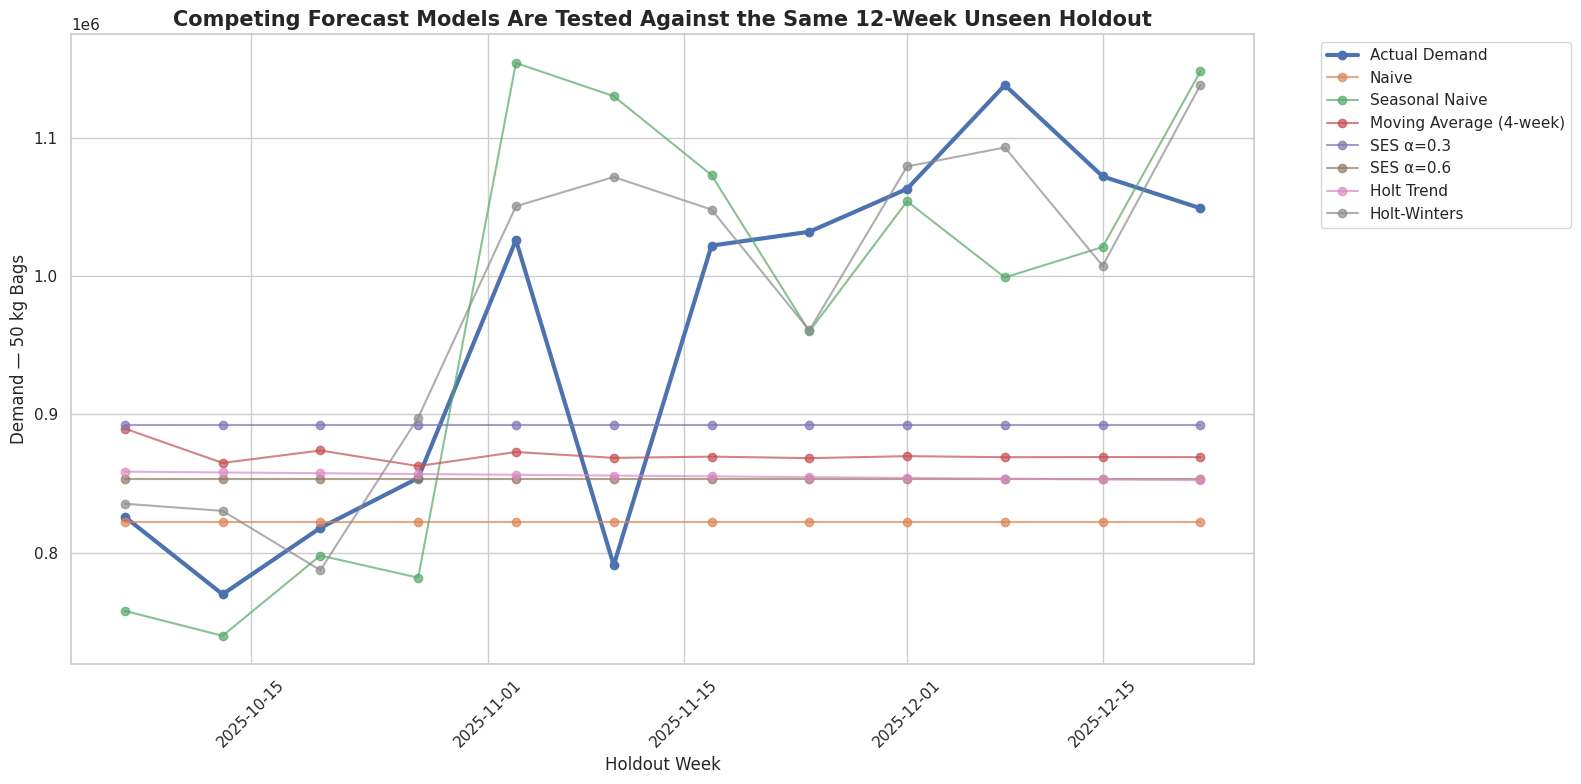

In [39]:
plt.figure(figsize=(16, 8))

plt.plot(
    test_df["Week_Start_Date"],
    actual_holdout,
    marker="o",
    linewidth=3,
    label="Actual Demand"
)

for model_name, forecast in model_forecasts.items():

    plt.plot(
        test_df["Week_Start_Date"],
        forecast,
        marker="o",
        alpha=0.7,
        label=model_name
    )

plt.title(
    "Competing Forecast Models Are Tested Against the Same 12-Week Unseen Holdout",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Holdout Week")
plt.ylabel("Demand — 50 kg Bags")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

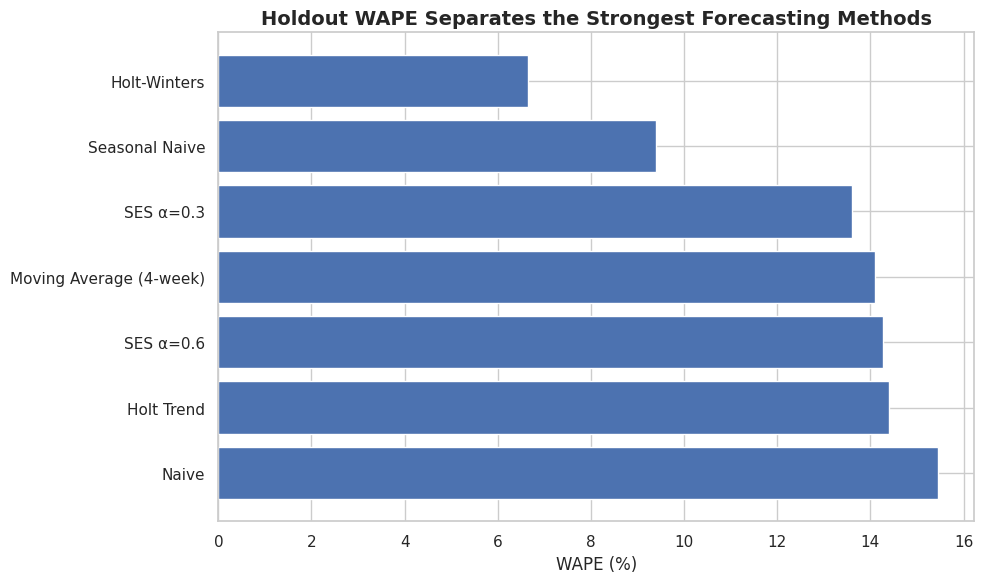

In [40]:
ranking = (
    model_comparison
    .sort_values("WAPE", ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    ranking["Model"],
    ranking["WAPE"]
)

plt.title(
    "Holdout WAPE Separates the Strongest Forecasting Methods",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("WAPE (%)")
plt.ylabel("")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [41]:
display_table

,Model,MAD,MAPE,RMSE,WAPE,Bias,RSFE,Tracking Signal
0,Holt-Winters,63431,7.09,94008,6.64,-28192,-338306,-5.33
1,Seasonal Naive,89833,9.80,123154,9.41,-13000,-156000,-1.74
2,SES α=0.3,129916,13.24,140717,13.60,63079,756947,5.83
3,Moving Average (4-week),134579,13.44,152459,14.09,84439,1013266,7.53
4,SES α=0.6,136369,13.40,161594,14.28,101441,1217288,8.93
5,Holt Trend,137551,13.55,161711,14.40,99573,1194877,8.69
6,Naive,147583,14.22,183122,15.45,133083,1597000,10.82


In [42]:
# ============================================================
# STAGE 6 — HOLDOUT VALIDATION
# Selected candidate: Holt-Winters
# ============================================================

validation_df = test_df[
    [
        "Week_Start_Date",
        "Actual_Demand_Bags",
        "Promo_Flag",
        "Promo_Depth_Pct",
        "Event_Flag",
        "Agricultural_Season",
        "Distribution_Points",
        "Stockout_Flag",
        "Exceptional_Event"
    ]
].copy()

validation_df["Holt_Winters_Forecast"] = hw_forecast

validation_df["Error"] = (
    validation_df["Actual_Demand_Bags"]
    - validation_df["Holt_Winters_Forecast"]
)

validation_df["Absolute_Error"] = (
    validation_df["Error"].abs()
)

validation_df["APE_Pct"] = (
    validation_df["Absolute_Error"]
    / validation_df["Actual_Demand_Bags"]
) * 100

validation_df

,Week_Start_Date,Actual_Demand_Bags,Promo_Flag,Promo_Depth_Pct,Event_Flag,Agricultural_Season,Distribution_Points,Stockout_Flag,Exceptional_Event,Holt_Winters_Forecast,Error,Absolute_Error,APE_Pct
144,2025-10-06,826000,0,0.00,0,Normal / shoulder period,1032,0,NaN,8.354065e+05,-9406.513118,9406.513118,1.138803
145,2025-10-13,770000,0,0.00,0,Normal / shoulder period,1061,0,NaN,8.302754e+05,-60275.351850,60275.351850,7.827968
146,2025-10-20,818000,0,0.00,0,Normal / shoulder period,1055,0,NaN,7.874396e+05,30560.409618,30560.409618,3.735991
147,2025-10-27,854000,1,0.04,0,Normal / shoulder period,1021,0,NaN,8.975793e+05,-43579.259123,43579.259123,5.102958
148,2025-11-03,1026000,0,0.00,1,Rabi demand window,1070,0,NaN,1.050469e+06,-24468.700755,24468.700755,2.384864
149,2025-11-10,791000,0,0.00,1,Rabi demand window,1039,1,NaN,1.071590e+06,-280590.241664,280590.241664,35.472850
150,2025-11-17,1022000,0,0.00,1,Rabi demand window,1043,0,NaN,1.048038e+06,-26037.811017,26037.811017,2.547731
151,2025-11-24,1032000,0,0.00,1,Rabi demand window,1050,0,NaN,9.607604e+05,71239.640869,71239.640869,6.903066
152,2025-12-01,1063000,0,0.00,1,Rabi demand window,1055,0,NaN,1.079219e+06,-16219.423798,16219.423798,1.525816
153,2025-12-08,1138000,0,0.00,1,Rabi demand window,1031,0,NaN,1.092950e+06,45050.331267,45050.331267,3.958729


In [43]:
top_5_misses = (
    validation_df
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
    .head(5)
    .copy()
)

top_5_misses[
    [
        "Week_Start_Date",
        "Actual_Demand_Bags",
        "Holt_Winters_Forecast",
        "Error",
        "Absolute_Error",
        "APE_Pct",
        "Promo_Flag",
        "Event_Flag",
        "Stockout_Flag",
        "Exceptional_Event"
    ]
]

,Week_Start_Date,Actual_Demand_Bags,Holt_Winters_Forecast,Error,Absolute_Error,APE_Pct,Promo_Flag,Event_Flag,Stockout_Flag,Exceptional_Event
149,2025-11-10,791000,1.071590e+06,-280590.241664,280590.241664,35.472850,0,1,1,NaN
155,2025-12-22,1049000,1.138159e+06,-89158.962956,89158.962956,8.499424,0,1,0,NaN
151,2025-11-24,1032000,9.607604e+05,71239.640869,71239.640869,6.903066,0,1,0,NaN
154,2025-12-15,1072000,1.007420e+06,64579.741693,64579.741693,6.024230,1,1,0,NaN
145,2025-10-13,770000,8.302754e+05,-60275.351850,60275.351850,7.827968,0,0,0,NaN


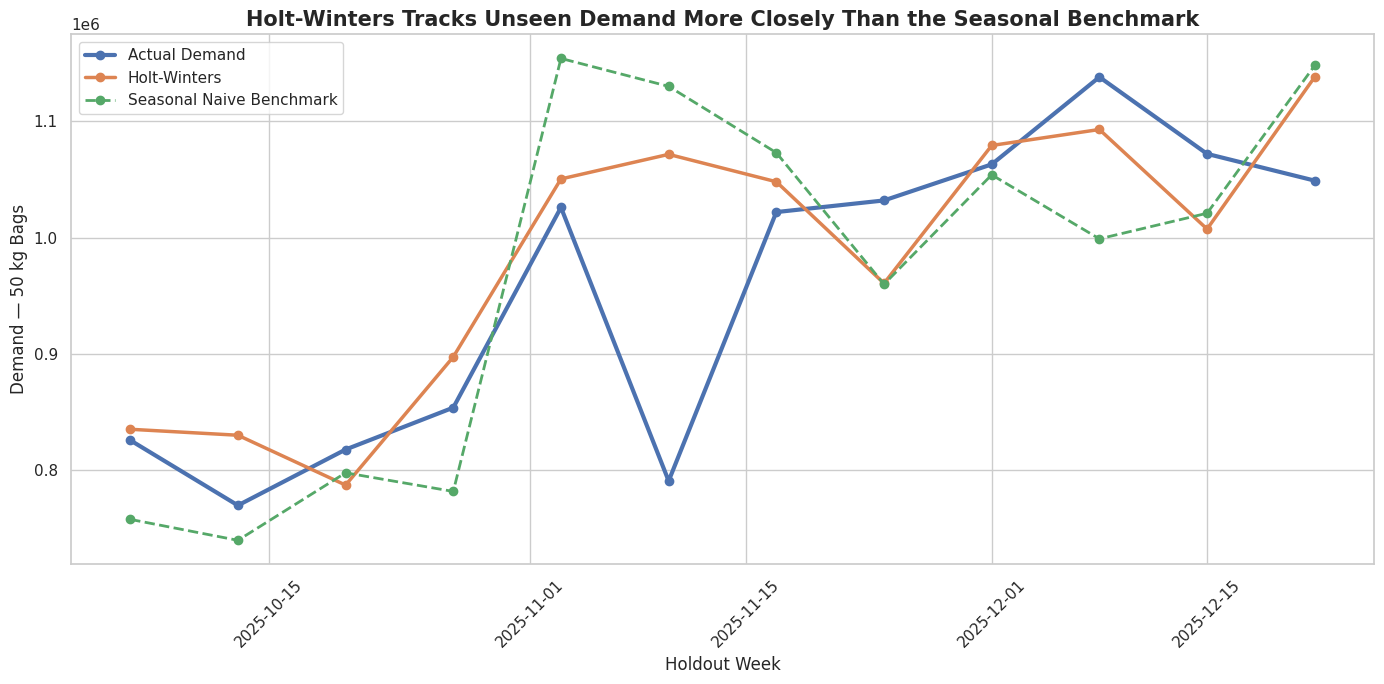

In [44]:
plt.figure(figsize=(14, 7))

plt.plot(
    test_df["Week_Start_Date"],
    actual_holdout,
    marker="o",
    linewidth=3,
    label="Actual Demand"
)

plt.plot(
    test_df["Week_Start_Date"],
    hw_forecast,
    marker="o",
    linewidth=2.5,
    label="Holt-Winters"
)

plt.plot(
    test_df["Week_Start_Date"],
    seasonal_naive_forecast,
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Seasonal Naive Benchmark"
)

plt.title(
    "Holt-Winters Tracks Unseen Demand More Closely Than the Seasonal Benchmark",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Holdout Week")
plt.ylabel("Demand — 50 kg Bags")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

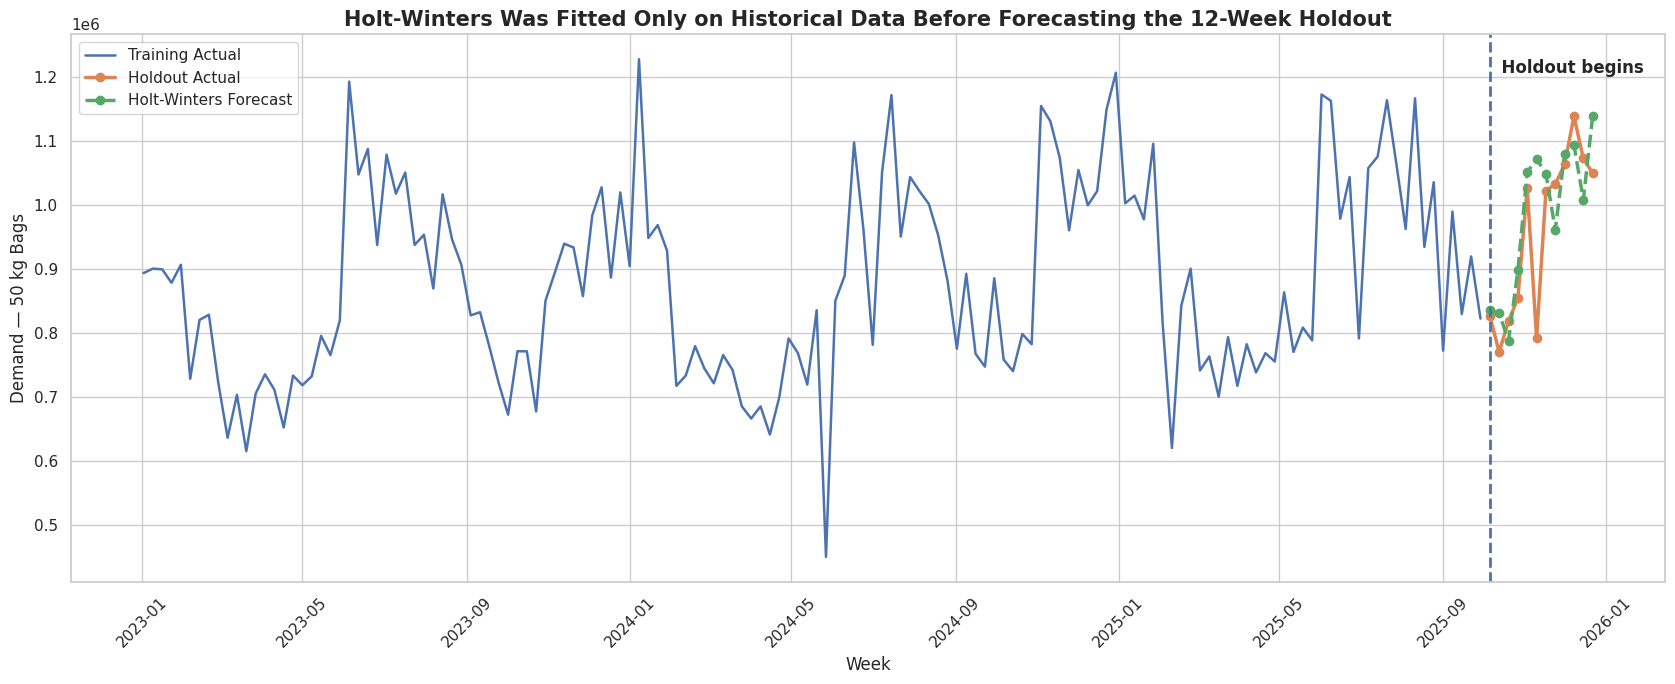

In [45]:
plt.figure(figsize=(17, 7))

plt.plot(
    train_df["Week_Start_Date"],
    train_df["Actual_Demand_Bags"],
    linewidth=1.8,
    label="Training Actual"
)

plt.plot(
    test_df["Week_Start_Date"],
    test_df["Actual_Demand_Bags"],
    marker="o",
    linewidth=2.5,
    label="Holdout Actual"
)

plt.plot(
    test_df["Week_Start_Date"],
    hw_forecast,
    marker="o",
    linestyle="--",
    linewidth=2.5,
    label="Holt-Winters Forecast"
)

split_date = test_df["Week_Start_Date"].iloc[0]

plt.axvline(
    split_date,
    linestyle="--",
    linewidth=2
)

plt.text(
    split_date,
    plt.ylim()[1] * 0.97,
    "  Holdout begins",
    verticalalignment="top",
    fontweight="bold"
)

plt.title(
    "Holt-Winters Was Fitted Only on Historical Data Before Forecasting the 12-Week Holdout",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Week")
plt.ylabel("Demand — 50 kg Bags")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

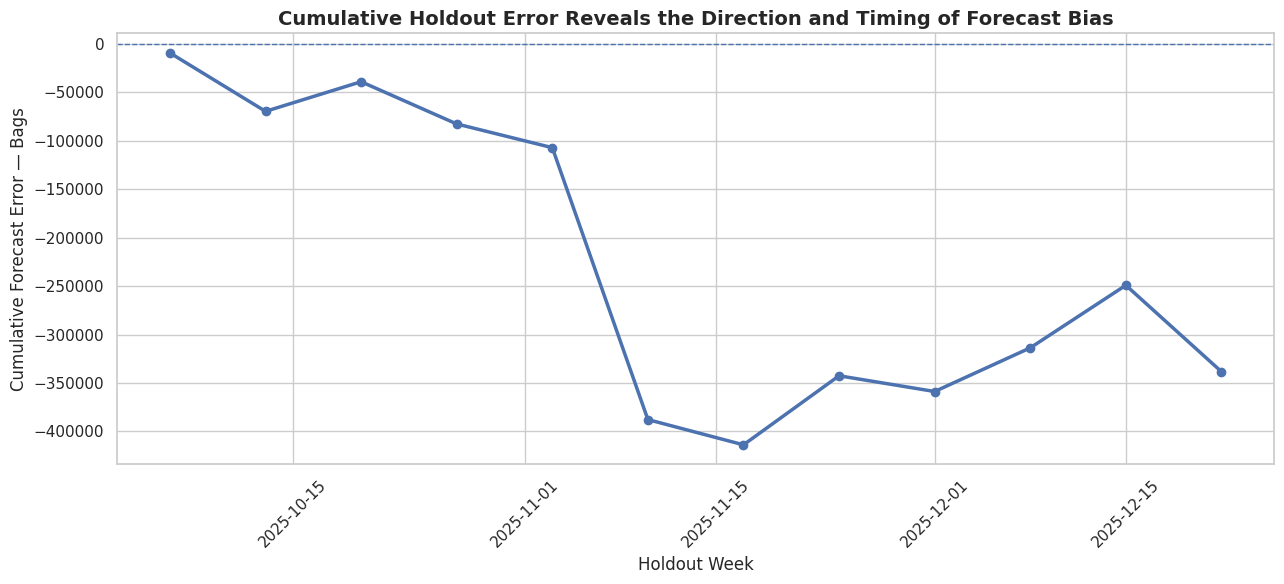

In [46]:
validation_df["Cumulative_Error_RSFE"] = (
    validation_df["Error"].cumsum()
)

plt.figure(figsize=(13, 6))

plt.plot(
    validation_df["Week_Start_Date"],
    validation_df["Cumulative_Error_RSFE"],
    marker="o",
    linewidth=2.5
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Cumulative Holdout Error Reveals the Direction and Timing of Forecast Bias",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Holdout Week")
plt.ylabel("Cumulative Forecast Error — Bags")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

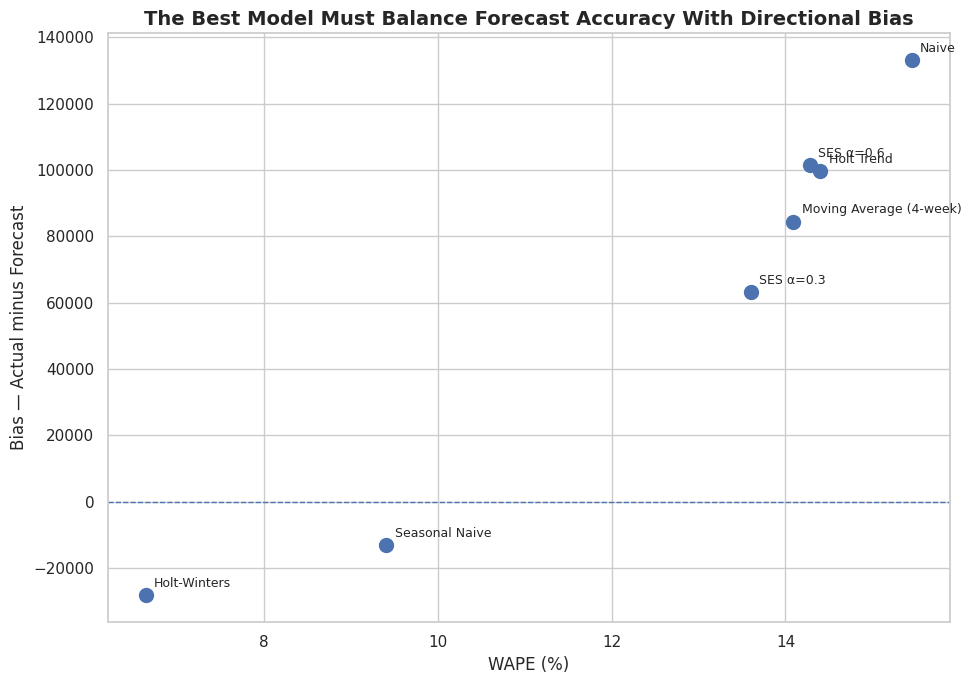

In [47]:
plt.figure(figsize=(10, 7))

plt.scatter(
    model_comparison["WAPE"],
    model_comparison["Bias"],
    s=100
)

for _, row in model_comparison.iterrows():

    plt.annotate(
        row["Model"],
        (
            row["WAPE"],
            row["Bias"]
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "The Best Model Must Balance Forecast Accuracy With Directional Bias",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("WAPE (%)")
plt.ylabel("Bias — Actual minus Forecast")

plt.tight_layout()
plt.show()

In [48]:
print("LEAKAGE AUDIT")
print("-------------")

print(
    "Training rows used for model fitting:",
    len(train_df)
)

print(
    "Holdout rows excluded from fitting:",
    len(test_df)
)

print(
    "Training ends:",
    train_df["Week_Start_Date"].max()
)

print(
    "Holdout begins:",
    test_df["Week_Start_Date"].min()
)

print(
    "\nHolt-Winters was fitted only on train_df."
)

print(
    "No Actual_Demand_Bags values from test_df were supplied during model fitting."
)

print(
    "The 12 holdout actual values were revealed only after forecasts had been generated for evaluation."
)

print(
    "\nConclusion: No holdout leakage occurred."
)

LEAKAGE AUDIT
-------------
Training rows used for model fitting: 144
Holdout rows excluded from fitting: 12
Training ends: 2025-09-29 00:00:00
Holdout begins: 2025-10-06 00:00:00

Holt-Winters was fitted only on train_df.
No Actual_Demand_Bags values from test_df were supplied during model fitting.
The 12 holdout actual values were revealed only after forecasts had been generated for evaluation.

Conclusion: No holdout leakage occurred.


In [49]:
# ============================================================
# STAGE 7 — MULTIPLE REGRESSION / DEMAND DRIVERS
# Regression fitted on TRAINING DATA ONLY
# ============================================================

import statsmodels.api as sm
import pandas as pd
import numpy as np

In [50]:
regression_vars = [
    "Price_PKR_Per_Bag",
    "Promo_Flag",
    "Event_Flag",
    "Distribution_Points"
]

X = train_df[regression_vars].copy()

y = train_df["Actual_Demand_Bags"].copy()

# Add regression intercept
X = sm.add_constant(X)

print("Regression observations:", len(X))

X.head()

Regression observations: 144


,const,Price_PKR_Per_Bag,Promo_Flag,Event_Flag,Distribution_Points
0,1.0,3450,0,1,978
1,1.0,3490,0,1,967
2,1.0,3470,0,1,939
3,1.0,3490,0,1,968
4,1.0,3410,0,1,955


In [51]:
reg_model = sm.OLS(
    y,
    X
).fit()

print(reg_model.summary())

                            OLS Regression Results                            
Dep. Variable:     Actual_Demand_Bags   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     154.4
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           4.11e-50
Time:                        05:08:51   Log-Likelihood:                -1800.0
No. Observations:                 144   AIC:                             3610.
Df Residuals:                     139   BIC:                             3625.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               -4.922e+05   2

In [52]:
regression_results = pd.DataFrame({
    "Variable": reg_model.params.index,
    "Coefficient": reg_model.params.values,
    "P_Value": reg_model.pvalues.values,
    "Std_Error": reg_model.bse.values,
    "CI_Lower": reg_model.conf_int()[0].values,
    "CI_Upper": reg_model.conf_int()[1].values
})

regression_results

,Variable,Coefficient,P_Value,Std_Error,CI_Lower,CI_Upper
0,const,-492182.895022,4.760074e-02,246262.299244,-979087.227465,-5278.562579
1,Price_PKR_Per_Bag,-17.653355,1.954532e-01,13.570355,-44.484357,9.177648
2,Promo_Flag,148008.299531,6.022045e-18,14873.290900,118601.160074,177415.438988
3,Event_Flag,230688.763844,1.697677e-44,11095.938115,208750.122172,252627.405517
4,Distribution_Points,1300.508883,5.904230e-06,276.045548,754.717776,1846.299991


In [53]:
regression_display = regression_results.copy()

regression_display["Coefficient"] = (
    regression_display["Coefficient"].round(2)
)

regression_display["P_Value"] = (
    regression_display["P_Value"].round(4)
)

regression_display["Std_Error"] = (
    regression_display["Std_Error"].round(2)
)

regression_display["CI_Lower"] = (
    regression_display["CI_Lower"].round(2)
)

regression_display["CI_Upper"] = (
    regression_display["CI_Upper"].round(2)
)

regression_display

,Variable,Coefficient,P_Value,Std_Error,CI_Lower,CI_Upper
0,const,-492182.90,0.0476,246262.30,-979087.23,-5278.56
1,Price_PKR_Per_Bag,-17.65,0.1955,13.57,-44.48,9.18
2,Promo_Flag,148008.30,0.0000,14873.29,118601.16,177415.44
3,Event_Flag,230688.76,0.0000,11095.94,208750.12,252627.41
4,Distribution_Points,1300.51,0.0000,276.05,754.72,1846.30


In [54]:
print(f"R-squared: {reg_model.rsquared:.4f}")
print(f"Adjusted R-squared: {reg_model.rsquared_adj:.4f}")
print(f"F-statistic: {reg_model.fvalue:.2f}")
print(f"Model p-value: {reg_model.f_pvalue:.6f}")
print(f"Number of observations: {int(reg_model.nobs)}")

R-squared: 0.8163
Adjusted R-squared: 0.8110
F-statistic: 154.44
Model p-value: 0.000000
Number of observations: 144


In [55]:
intercept = reg_model.params["const"]

price_coef = reg_model.params["Price_PKR_Per_Bag"]
promo_coef = reg_model.params["Promo_Flag"]
event_coef = reg_model.params["Event_Flag"]
distribution_coef = reg_model.params["Distribution_Points"]

print(f"Intercept: {intercept:,.2f}")

print(
    f"Price coefficient: "
    f"{price_coef:,.2f} bags per PKR"
)

print(
    f"Promotion coefficient: "
    f"{promo_coef:,.2f} bags"
)

print(
    f"Event coefficient: "
    f"{event_coef:,.2f} bags"
)

print(
    f"Distribution Points coefficient: "
    f"{distribution_coef:,.2f} bags per point"
)

Intercept: -492,182.90
Price coefficient: -17.65 bags per PKR
Promotion coefficient: 148,008.30 bags
Event coefficient: 230,688.76 bags
Distribution Points coefficient: 1,300.51 bags per point


In [56]:
def significance_label(p):
    if p < 0.01:
        return "Strong statistical evidence (p < 0.01)"
    elif p < 0.05:
        return "Statistically significant at 5%"
    elif p < 0.10:
        return "Weak / marginal statistical evidence"
    else:
        return "Not statistically significant at conventional levels"


significance_table = regression_results[
    ["Variable", "Coefficient", "P_Value"]
].copy()

significance_table["Evidence"] = (
    significance_table["P_Value"]
    .apply(significance_label)
)

significance_table

,Variable,Coefficient,P_Value,Evidence
0,const,-492182.895022,4.760074e-02,Statistically significant at 5%
1,Price_PKR_Per_Bag,-17.653355,1.954532e-01,Not statistically significant at conventional ...
2,Promo_Flag,148008.299531,6.022045e-18,Strong statistical evidence (p < 0.01)
3,Event_Flag,230688.763844,1.697677e-44,Strong statistical evidence (p < 0.01)
4,Distribution_Points,1300.508883,5.904230e-06,Strong statistical evidence (p < 0.01)


In [57]:
print("EXPECTED BUSINESS DIRECTIONS")
print("----------------------------")

print("Price:")
print("Expected sign = Negative")
print(f"Observed coefficient = {price_coef:,.2f}")

print("\nPromotion:")
print("Expected sign = Positive")
print(f"Observed coefficient = {promo_coef:,.2f}")

print("\nAgricultural Event:")
print("Expected sign = Positive")
print(f"Observed coefficient = {event_coef:,.2f}")

print("\nDistribution Points:")
print("Expected sign = Positive")
print(f"Observed coefficient = {distribution_coef:,.2f}")

EXPECTED BUSINESS DIRECTIONS
----------------------------
Price:
Expected sign = Negative
Observed coefficient = -17.65

Promotion:
Expected sign = Positive
Observed coefficient = 148,008.30

Agricultural Event:
Expected sign = Positive
Observed coefficient = 230,688.76

Distribution Points:
Expected sign = Positive
Observed coefficient = 1,300.51


In [58]:
price_scenarios = pd.DataFrame({
    "Price_Change_PKR": [-200, -100, -50, 50, 100, 200]
})

price_scenarios["Associated_Demand_Change_Bags"] = (
    price_scenarios["Price_Change_PKR"]
    * price_coef
)

price_scenarios

,Price_Change_PKR,Associated_Demand_Change_Bags
0,-200,3530.670917
1,-100,1765.335459
2,-50,882.667729
3,50,-882.667729
4,100,-1765.335459
5,200,-3530.670917


In [59]:
train_mean_demand = (
    train_df["Actual_Demand_Bags"].mean()
)

promo_uplift_pct = (
    promo_coef / train_mean_demand
) * 100

print(
    f"Estimated promotion association: "
    f"{promo_coef:,.0f} bags/week"
)

print(
    f"Equivalent to approximately "
    f"{promo_uplift_pct:.1f}% "
    f"of average weekly demand."
)

Estimated promotion association: 148,008 bags/week
Equivalent to approximately 16.9% of average weekly demand.


In [60]:
distribution_10_point_effect = (
    distribution_coef * 10
)

distribution_25_point_effect = (
    distribution_coef * 25
)

print(
    f"Associated demand effect of +10 distribution points: "
    f"{distribution_10_point_effect:,.0f} bags/week"
)

print(
    f"Associated demand effect of +25 distribution points: "
    f"{distribution_25_point_effect:,.0f} bags/week"
)

Associated demand effect of +10 distribution points: 13,005 bags/week
Associated demand effect of +25 distribution points: 32,513 bags/week


In [61]:
driver_plot = regression_results[
    regression_results["Variable"] != "const"
].copy()

driver_plot

,Variable,Coefficient,P_Value,Std_Error,CI_Lower,CI_Upper
1,Price_PKR_Per_Bag,-17.653355,1.954532e-01,13.570355,-44.484357,9.177648
2,Promo_Flag,148008.299531,6.022045e-18,14873.290900,118601.160074,177415.438988
3,Event_Flag,230688.763844,1.697677e-44,11095.938115,208750.122172,252627.405517
4,Distribution_Points,1300.508883,5.904230e-06,276.045548,754.717776,1846.299991


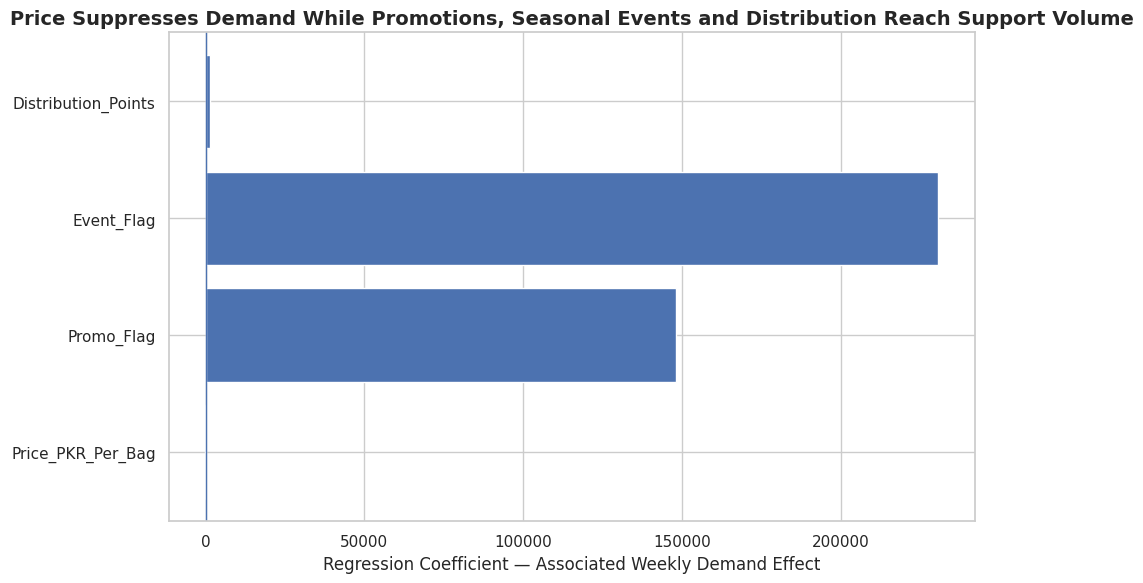

In [62]:
plt.figure(figsize=(10, 6))

plt.barh(
    driver_plot["Variable"],
    driver_plot["Coefficient"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.title(
    "Price Suppresses Demand While Promotions, Seasonal Events and Distribution Reach Support Volume",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Regression Coefficient — Associated Weekly Demand Effect")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [63]:
from sklearn.preprocessing import StandardScaler

standard_vars = [
    "Price_PKR_Per_Bag",
    "Promo_Flag",
    "Event_Flag",
    "Distribution_Points"
]

X_standardized = train_df[
    standard_vars
].copy()

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X_standardized),
    columns=standard_vars,
    index=X_standardized.index
)

y_scaled = (
    y - y.mean()
) / y.std()

X_scaled = sm.add_constant(X_scaled)

standard_model = sm.OLS(
    y_scaled,
    X_scaled
).fit()

standard_coefficients = (
    standard_model.params
    .drop("const")
    .sort_values()
)

standard_coefficients

,0
Price_PKR_Per_Bag,-0.059852
Distribution_Points,0.216582
Promo_Flag,0.362806
Event_Flag,0.758374


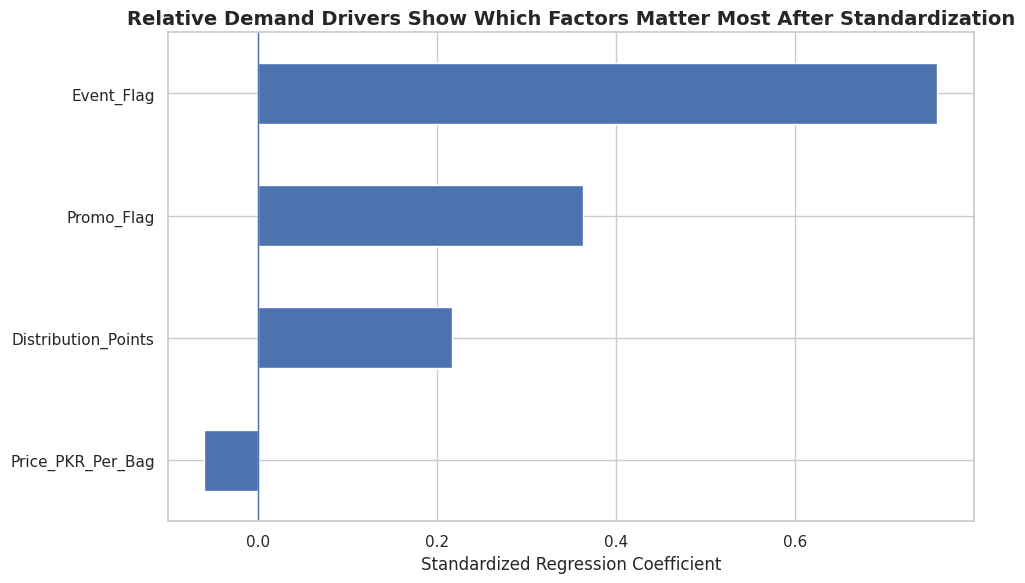

In [64]:
plt.figure(figsize=(10, 6))

standard_coefficients.plot(
    kind="barh"
)

plt.axvline(
    0,
    linewidth=1
)

plt.title(
    "Relative Demand Drivers Show Which Factors Matter Most After Standardization",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Standardized Regression Coefficient")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [65]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_X = train_df[
    regression_vars
].copy()

vif_X = sm.add_constant(vif_X)

vif_table = pd.DataFrame()

vif_table["Variable"] = vif_X.columns

vif_table["VIF"] = [
    variance_inflation_factor(
        vif_X.values,
        i
    )
    for i in range(vif_X.shape[1])
]

vif_table

,Variable,VIF
0,const,1.000000
1,Price_PKR_Per_Bag,1.613083
2,Promo_Flag,1.012899
3,Event_Flag,1.013952
4,Distribution_Points,1.610474


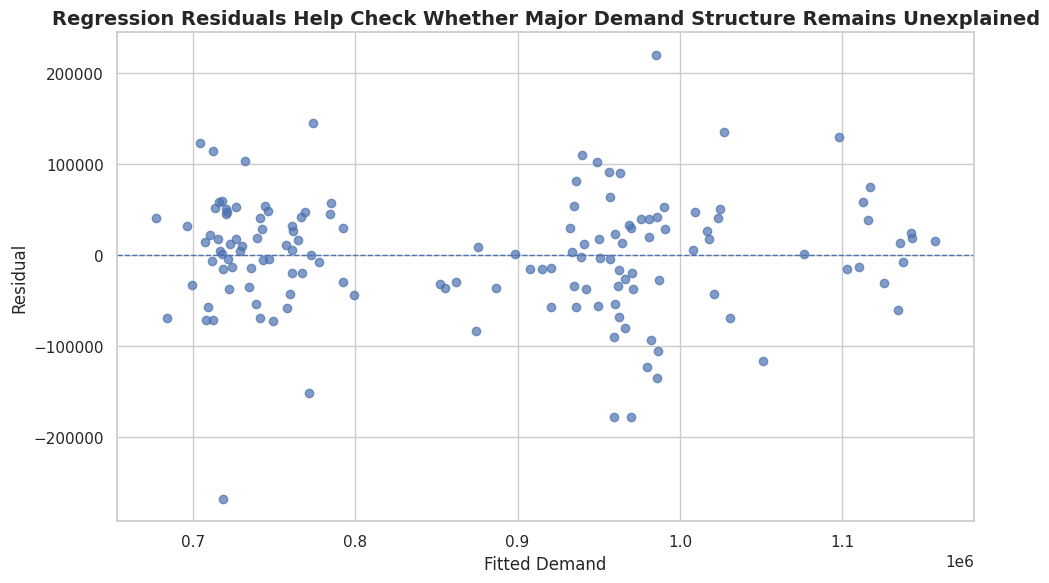

In [66]:
fitted_values = reg_model.fittedvalues
residuals = reg_model.resid

plt.figure(figsize=(10, 6))

plt.scatter(
    fitted_values,
    residuals,
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Regression Residuals Help Check Whether Major Demand Structure Remains Unexplained",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Fitted Demand")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()

### Regression / Demand Driver Analysis:
A multiple regression fitted on the 144-week training period explains approximately 81.6% of observed weekly demand variation, with an Adjusted R² of 81.1%. Agricultural event periods show the largest positive association, corresponding to approximately 230,689 additional 50 kg bags per week, holding the other included variables constant. Promotion weeks are associated with approximately 148,008 additional bags, while each additional distribution point is associated with roughly 1,301 additional bags per week. All three relationships are statistically significant at conventional levels. The estimated price coefficient is negative at approximately 18 fewer bags per PKR increase, but its p-value of 0.195 indicates insufficient statistical evidence to treat price as a reliable independent driver in this model. These coefficients should be interpreted as associations rather than causal effects because omitted factors may influence both the included variables and observed demand.

Important omitted influences include crop acreage, rainfall, regional fertilizer requirements, farmer economics, competitor pricing, dealer inventory, government policy and gas availability. Therefore, the regression supports planning associations rather than causal claims.

## Stage 8 — Forward Forecast, Stress Test & Operating Policy

After model selection on the untouched 12-week holdout, Holt-Winters is refitted on all 156 observed weeks for the true next-12-week operating forecast. This post-validation refit does not create leakage because model selection was completed before the forward forecast was generated.

In [104]:
# ============================================================
# FINAL FORWARD FORECAST
# Refit selected model on ALL 156 observed weeks
# Then forecast the NEXT 12 weeks
# ============================================================

from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pandas as pd
import numpy as np

# Full historical dataset
full_df = (
    df.sort_values("Week_Start_Date")
      .reset_index(drop=True)
      .copy()
)

# Refit Holt-Winters using ALL observed data
final_hw_model = ExponentialSmoothing(
    full_df["Actual_Demand_Bags"],
    trend="add",
    seasonal="add",
    seasonal_periods=52,
    initialization_method="estimated"
).fit(
    optimized=True
)

# Forecast the NEXT 12 weeks
forward_forecast = final_hw_model.forecast(12).values

# Generate future weekly dates
last_date = full_df["Week_Start_Date"].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(weeks=1),
    periods=12,
    freq="7D"
)

forward_df = pd.DataFrame({
    "Week_Start_Date": future_dates,
    "Forecast_Demand_Bags": forward_forecast
})

forward_df

,Week_Start_Date,Forecast_Demand_Bags
0,2025-12-29,1.108454e+06
1,2026-01-05,1.169680e+06
2,2026-01-12,1.036409e+06
3,2026-01-19,1.027242e+06
4,2026-01-26,1.065162e+06
5,2026-02-02,8.197217e+05
6,2026-02-09,7.290960e+05
7,2026-02-16,8.629705e+05
8,2026-02-23,8.744459e+05
9,2026-03-02,7.836300e+05


In [ ]:
# ============================================================
# CORRECTED FORWARD STRESS TEST
# ============================================================

base_total_bags = forward_df["Forecast_Demand_Bags"].sum()
average_weekly_forecast = forward_df["Forecast_Demand_Bags"].mean()
peak_weekly_forecast = forward_df["Forecast_Demand_Bags"].max()
peak_week_date = forward_df.loc[
    forward_df["Forecast_Demand_Bags"].idxmax(),
    "Week_Start_Date"
]

committed_bags = base_total_bags * 0.90
flexible_bags = base_total_bags * 0.10

upside_10 = base_total_bags * 1.10
upside_exposure = upside_10 - base_total_bags
supply_loss_shortage = base_total_bags * 0.10

# Apply +15% only to future agricultural-event weeks
forward_event_flag = (
    forward_df["Week_Start_Date"]
    .dt.month
    .isin([11, 12, 1, 6, 7, 8])
    .astype(int)
)

event_shock_weekly = (
    forward_df["Forecast_Demand_Bags"]
    * np.where(forward_event_flag == 1, 1.15, 1.00)
)

event_15 = event_shock_weekly.sum()
event_exposure = event_15 - base_total_bags

scenario_summary = pd.DataFrame({
    "Scenario": [
        "Downside -10%",
        "Base",
        "Upside +10%",
        "Event Weeks +15%",
        "Operational Supply Loss -10%"
    ],
    "Bags": [
        base_total_bags * 0.90,
        base_total_bags,
        upside_10,
        event_15,
        base_total_bags * 0.90
    ],
    "Difference_vs_Base": [
        -base_total_bags * 0.10,
        0,
        upside_exposure,
        event_exposure,
        -supply_loss_shortage
    ]
})

scenario_summary["Tonnes_Equivalent"] = (
    scenario_summary["Difference_vs_Base"].abs() * 0.05
)

scenario_summary


                       Scenario          Bags  Difference_vs_Base  Tonnes_Equivalent
0                 Downside -10%   9,960,039             -1,106,671              55,334
1                          Base  11,066,710                      0                   0
2                   Upside +10%  12,173,381              1,106,671              55,334
3              Event Weeks +15%  11,877,752                811,042              40,552
4  Operational Supply Loss -10%   9,960,039             -1,106,671              55,334


### Final Recommended Operating Policy

**Use Holt-Winters as the primary next-12-week planning forecast. Plan against 11.07 million 50 kg bags, commit approximately 9.96 million bags (90%) through production and distributor replenishment, and retain approximately 1.11 million bags (10%) as responsive volume. Maintain approximately 0.81 million bags of additional event-week readiness if agricultural-event demand is 15% stronger than the base forecast. Reforecast if either of the first two weeks deviates from forecast by more than 10%, if Tracking Signal deteriorates materially, or if an operational disruption threatens more than 5% of planned supply.**

In [118]:
# ============================================================
# SINGLE-PAGE EXECUTIVE FORECASTING DASHBOARD
# MGT-353 | SUPPLY CHAIN ANALYTICS
# EFERT | ENGRO UREA — 50 KG BAG
# ============================================================

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio

from IPython.display import HTML, display


# ============================================================
# 0. VISUAL SYSTEM
# PERSONAL EXECUTIVE THEME
# ============================================================

COLORS = {
    # Core identity
    "primary": "#253B80",        # deep indigo
    "secondary": "#5B4BC4",      # violet

    # Action / forecast accent
    "accent": "#2878F0",         # electric blue
    "accent_light": "#65A5FF",

    # Seasonal / agricultural emphasis
    "gold": "#F2B84B",

    # Canvas
    "background": "#F6F7FB",
    "card": "#FFFFFF",

    # Typography
    "text": "#20233A",
    "muted": "#6D7187",

    # Risk language
    "warning": "#F08A5D",
    "risk": "#E45B67",

    # Secondary
    "gray": "#A9AEC2",
    "light_gray": "#E9EBF4",
    "grid": "#DDE1EE",

    # Borders
    "border": "#E2DFE5"
}


# ============================================================
# 1. FORWARD-PLANNING KPIs
# FINAL Holt-Winters model refitted on all observed history
# ============================================================

base_total_bags = (
    forward_df["Forecast_Demand_Bags"].sum()
)

average_weekly_forecast = (
    forward_df["Forecast_Demand_Bags"].mean()
)

peak_weekly_forecast = (
    forward_df["Forecast_Demand_Bags"].max()
)

peak_week_date = (
    forward_df.loc[
        forward_df["Forecast_Demand_Bags"].idxmax(),
        "Week_Start_Date"
    ]
)


# ------------------------------------------------------------
# DECISION POLICY
# ------------------------------------------------------------

committed_bags = (
    base_total_bags * 0.90
)

flexible_bags = (
    base_total_bags * 0.10
)

upside_10 = (
    base_total_bags * 1.10
)

upside_exposure = (
    upside_10 - base_total_bags
)

supply_loss_shortage = (
    base_total_bags * 0.10
)


# ============================================================
# 2. FUTURE AGRICULTURAL EVENT SHOCK
# +15% ONLY DURING FUTURE EVENT-WINDOW WEEKS
# ============================================================

forward_event_flag = (
    forward_df["Week_Start_Date"]
    .dt.month
    .isin([11, 12, 1, 6, 7, 8])
    .astype(int)
)

event_shock_weekly = (
    forward_df["Forecast_Demand_Bags"]
    * np.where(
        forward_event_flag == 1,
        1.15,
        1.00
    )
)

event_15 = (
    event_shock_weekly.sum()
)

event_exposure = (
    event_15 - base_total_bags
)


# ============================================================
# 3. VALIDATED HOLDOUT PERFORMANCE
# PULL DIRECTLY FROM MODEL COMPARISON TABLE
# ============================================================

hw_row = (
    model_comparison.loc[
        model_comparison["Model"] == "Holt-Winters"
    ]
    .iloc[0]
)

best_wape = hw_row["WAPE"]
best_mape = hw_row["MAPE"]
best_mad = hw_row["MAD"]
best_bias = hw_row["Bias"]
best_tracking_signal = hw_row["Tracking Signal"]


# ============================================================
# 4. REGRESSION VALUES
# ============================================================

price_coef = (
    reg_model.params["Price_PKR_Per_Bag"]
)

promo_coef = (
    reg_model.params["Promo_Flag"]
)

event_coef = (
    reg_model.params["Event_Flag"]
)

distribution_coef = (
    reg_model.params["Distribution_Points"]
)

r2 = reg_model.rsquared
adj_r2 = reg_model.rsquared_adj


# ============================================================
# 5. EMPIRICAL FORWARD UNCERTAINTY BAND
#
# Uses holdout forecast-error variability.
# This is an empirical validation-error band,
# NOT a formal statistical prediction interval.
# ============================================================

holdout_errors = (
    test_df["Actual_Demand_Bags"].values
    - np.asarray(hw_forecast)
)

validation_error_sd = (
    np.std(
        holdout_errors,
        ddof=1
    )
)

uncertainty_width = (
    1.96 * validation_error_sd
)

forward_df_dashboard = (
    forward_df.copy()
)

forward_df_dashboard[
    "Lower_Band"
] = np.maximum(
    0,
    forward_df_dashboard["Forecast_Demand_Bags"]
    - uncertainty_width
)

forward_df_dashboard[
    "Upper_Band"
] = (
    forward_df_dashboard["Forecast_Demand_Bags"]
    + uncertainty_width
)


# ============================================================
# 6. CHART 1
# HISTORY + HOLDOUT VALIDATION + NEXT 12-WEEK FORECAST
# ============================================================

fig_history = go.Figure()


# ------------------------------------------------------------
# TRAINING ACTUAL
# ------------------------------------------------------------

fig_history.add_trace(
    go.Scatter(
        x=train_df["Week_Start_Date"],
        y=train_df["Actual_Demand_Bags"],
        mode="lines",
        name="Training Actual",

        line=dict(
            color="#9B9CAE",
            width=2
        )
    )
)


# ------------------------------------------------------------
# HOLDOUT ACTUAL
# ------------------------------------------------------------

fig_history.add_trace(
    go.Scatter(
        x=test_df["Week_Start_Date"],
        y=test_df["Actual_Demand_Bags"],
        mode="lines+markers",
        name="Holdout Actual",

        line=dict(
            color=COLORS["primary"],
            width=3
        ),

        marker=dict(
            size=6
        )
    )
)


# ------------------------------------------------------------
# HOLDOUT FORECAST
# ------------------------------------------------------------

fig_history.add_trace(
    go.Scatter(
        x=test_df["Week_Start_Date"],
        y=hw_forecast,
        mode="lines+markers",
        name="Holdout Forecast",

        line=dict(
            color=COLORS["accent"],
            width=3,
            dash="dash"
        ),

        marker=dict(
            size=6
        )
    )
)


# ------------------------------------------------------------
# FORWARD UNCERTAINTY — UPPER
# ------------------------------------------------------------

fig_history.add_trace(
    go.Scatter(
        x=forward_df_dashboard["Week_Start_Date"],
        y=forward_df_dashboard["Upper_Band"],

        mode="lines",

        line=dict(
            width=0
        ),

        hoverinfo="skip",

        showlegend=False
    )
)


# ------------------------------------------------------------
# FORWARD UNCERTAINTY — LOWER + FILL
# ------------------------------------------------------------

fig_history.add_trace(
    go.Scatter(
        x=forward_df_dashboard["Week_Start_Date"],
        y=forward_df_dashboard["Lower_Band"],

        mode="lines",

        fill="tonexty",

        fillcolor="rgba(40,120,240,0.10)",

        line=dict(
            width=0
        ),

        name="Empirical Uncertainty Band",

        hoverinfo="skip"
    )
)


# ------------------------------------------------------------
# NEXT 12-WEEK FORECAST
# ------------------------------------------------------------

fig_history.add_trace(
    go.Scatter(
        x=forward_df_dashboard["Week_Start_Date"],
        y=forward_df_dashboard["Forecast_Demand_Bags"],

        mode="lines+markers",

        name="Next 12-Week Forecast",

        line=dict(
            color=COLORS["secondary"],
            width=4
        ),

        marker=dict(
            size=7
        )
    )
)


# ------------------------------------------------------------
# HOLDOUT START
# ------------------------------------------------------------

fig_history.add_vline(
    x=test_df["Week_Start_Date"].iloc[0],

    line_dash="dot",

    line_color=COLORS["muted"]
)


# ------------------------------------------------------------
# FORWARD PLAN START
# ------------------------------------------------------------

fig_history.add_vline(
    x=forward_df_dashboard["Week_Start_Date"].iloc[0],

    line_dash="dot",

    line_color=COLORS["secondary"]
)


fig_history.add_annotation(
    x=forward_df_dashboard["Week_Start_Date"].iloc[0],

    y=1,

    xref="x",
    yref="paper",

    text="Forward plan",

    showarrow=False,

    yshift=12,

    font=dict(
        size=10,
        color=COLORS["secondary"]
    )
)


fig_history.update_layout(
    title=dict(
        text=(
            "<b>Validated on the Holdout, Holt-Winters "
            "Extends the Next 12 Weeks Forward</b>"
        ),

        font=dict(
            size=14,
            color=COLORS["text"]
        )
    ),

    height=410,

    template="plotly_white",

    paper_bgcolor=COLORS["card"],
    plot_bgcolor=COLORS["card"],

    font=dict(
        family="Inter, Arial, sans-serif",
        color=COLORS["text"]
    ),

    margin=dict(
        l=55,
        r=20,
        t=72,
        b=40
    ),

    xaxis_title="Week",

    yaxis_title=(
        "Demand — 50 kg Bags"
    ),

    hovermode="x unified",

    legend=dict(
        orientation="h",
        y=1.15,
        x=0,
        font=dict(size=9)
    ),

    xaxis=dict(
        gridcolor=COLORS["grid"]
    ),

    yaxis=dict(
        gridcolor=COLORS["grid"]
    )
)


# ============================================================
# 7. CHART 2 — MODEL ACCURACY
# ============================================================

model_rank = (
    model_comparison
    .sort_values(
        "WAPE",
        ascending=True
    )
    .copy()
)


fig_models = go.Figure()


fig_models.add_trace(
    go.Bar(
        x=model_rank["WAPE"],
        y=model_rank["Model"],

        orientation="h",

        text=[
            f"{x:.2f}%"
            for x in model_rank["WAPE"]
        ],

        textposition="outside",

        marker=dict(
            color=[
                COLORS["accent"]
                if x == "Holt-Winters"
                else COLORS["gray"]

                for x
                in model_rank["Model"]
            ]
        )
    )
)


fig_models.update_layout(
    title=dict(
        text=(
            "<b>Holt-Winters Earned Trust "
            "on Unseen Data</b>"
        ),

        font=dict(
            size=14,
            color=COLORS["text"]
        )
    ),

    height=410,

    template="plotly_white",

    paper_bgcolor=COLORS["card"],
    plot_bgcolor=COLORS["card"],

    font=dict(
        family="Inter, Arial, sans-serif",
        color=COLORS["text"]
    ),

    margin=dict(
        l=120,
        r=40,
        t=72,
        b=40
    ),

    xaxis_title=(
        "Holdout WAPE (%) — Lower is Better"
    ),

    yaxis_title="",

    yaxis=dict(
        autorange="reversed"
    ),

    xaxis=dict(
        gridcolor=COLORS["grid"]
    ),

    showlegend=False
)


# ============================================================
# 8. CHART 3 — FORECAST ERROR / BIAS
# ============================================================

validation_dashboard = (
    test_df[
        [
            "Week_Start_Date",
            "Actual_Demand_Bags"
        ]
    ]
    .copy()
)


validation_dashboard[
    "Forecast"
] = hw_forecast


validation_dashboard[
    "Error"
] = (
    validation_dashboard[
        "Actual_Demand_Bags"
    ]
    -
    validation_dashboard[
        "Forecast"
    ]
)


validation_dashboard[
    "Cumulative_Error"
] = (
    validation_dashboard[
        "Error"
    ]
    .cumsum()
)


fig_bias = go.Figure()


fig_bias.add_trace(
    go.Bar(
        x=validation_dashboard[
            "Week_Start_Date"
        ],

        y=validation_dashboard[
            "Error"
        ],

        name="Weekly Error",

        marker_color=[
            COLORS["risk"]
            if x < 0
            else COLORS["accent"]

            for x
            in validation_dashboard["Error"]
        ]
    )
)


fig_bias.add_hline(
    y=0,

    line_color=COLORS["primary"],

    line_width=1
)


fig_bias.update_layout(
    title=dict(
        text=(
            "<b>Negative Errors Reveal "
            "an Over-Forecast Tendency</b>"
        ),

        font=dict(
            size=14,
            color=COLORS["text"]
        )
    ),

    height=350,

    template="plotly_white",

    paper_bgcolor=COLORS["card"],
    plot_bgcolor=COLORS["card"],

    font=dict(
        family="Inter, Arial, sans-serif",
        color=COLORS["text"]
    ),

    margin=dict(
        l=55,
        r=20,
        t=70,
        b=40
    ),

    xaxis_title="Holdout Week",

    yaxis_title=(
        "Actual − Forecast (Bags)"
    ),

    xaxis=dict(
        gridcolor=COLORS["grid"]
    ),

    yaxis=dict(
        gridcolor=COLORS["grid"]
    ),

    showlegend=False
)


# ============================================================
# 9. CHART 4 — STRESS TEST
# ============================================================

scenario_table = pd.DataFrame({
    "Scenario": [
        "Downside -10%",
        "Base",
        "Upside +10%",
        "Event Weeks +15%"
    ],

    "Demand": [
        base_total_bags * 0.90,
        base_total_bags,
        upside_10,
        event_15
    ]
})


fig_scenario = go.Figure()


fig_scenario.add_trace(
    go.Bar(
        x=scenario_table["Scenario"],

        y=scenario_table["Demand"],

        text=[
            f"{x / 1_000_000:.2f}M"
            for x
            in scenario_table["Demand"]
        ],

        textposition="outside",

        marker_color=[
            COLORS["accent_light"],
            COLORS["secondary"],
            COLORS["warning"],
            COLORS["risk"]
        ]
    )
)


fig_scenario.add_hline(
    y=base_total_bags,

    line_dash="dash",

    line_color=COLORS["primary"],

    annotation_text="Base Plan"
)


fig_scenario.update_layout(
    title=dict(
        text=(
            "<b>Downside Is Absorbed; Upside and Event "
            "Intensity Require Additional Readiness</b>"
        ),

        font=dict(
            size=14,
            color=COLORS["text"]
        )
    ),

    height=350,

    template="plotly_white",

    paper_bgcolor=COLORS["card"],
    plot_bgcolor=COLORS["card"],

    font=dict(
        family="Inter, Arial, sans-serif",
        color=COLORS["text"]
    ),

    margin=dict(
        l=55,
        r=20,
        t=70,
        b=40
    ),

    xaxis_title="",

    yaxis_title=(
        "12-Week Demand — Bags"
    ),

    yaxis=dict(
        gridcolor=COLORS["grid"]
    ),

    showlegend=False
)


# ============================================================
# 10. CONVERT PLOTLY CHARTS TO HTML
# ============================================================

history_html = pio.to_html(
    fig_history,

    include_plotlyjs="cdn",

    full_html=False,

    config={
        "displayModeBar": False,
        "responsive": True
    }
)


models_html = pio.to_html(
    fig_models,

    include_plotlyjs=False,

    full_html=False,

    config={
        "displayModeBar": False,
        "responsive": True
    }
)


bias_html = pio.to_html(
    fig_bias,

    include_plotlyjs=False,

    full_html=False,

    config={
        "displayModeBar": False,
        "responsive": True
    }
)


scenario_html = pio.to_html(
    fig_scenario,

    include_plotlyjs=False,

    full_html=False,

    config={
        "displayModeBar": False,
        "responsive": True
    }
)


# ============================================================
# 11. SINGLE-PAGE DASHBOARD HTML
# ============================================================

dashboard_html = f"""

<div style="
    font-family:
    Inter,
    ui-sans-serif,
    -apple-system,
    BlinkMacSystemFont,
    'Segoe UI',
    Arial,
    sans-serif;

    background:{COLORS["background"]};

    padding:20px;

    border-radius:7px;

    color:{COLORS["text"]};

    max-width:1680px;

    margin:auto;

    border:
    1px solid
    #D9D6CE;
">


<!-- ===================================================== -->
<!-- HEADER -->
<!-- ===================================================== -->

<div style="
    background:{COLORS["primary"]};

    color:white;

    padding:24px 28px;

    border-radius:7px;

    margin-bottom:12px;

    box-shadow:
    0 6px 18px
    rgba(37,59,128,0.12);
">


<div style="
font-size:29px;
font-weight:800;
letter-spacing:-0.7px;
">

EFERT Demand Planning Control Tower

</div>


<div style="
font-size:15px;
margin-top:5px;
opacity:0.92;
">

Engro Urea — 50 kg Bag |
12-Week Forecasting Intelligence Dashboard

</div>


<div style="
font-size:10px;
letter-spacing:1.7px;
font-weight:700;
margin-top:10px;
opacity:0.72;
">

FORECASTING / VALIDATION / DECISION SUPPORT

</div>


</div>


<!-- ===================================================== -->
<!-- SYNTHETIC DATA DISCLOSURE -->
<!-- ===================================================== -->

<div style="
    background:#EEF0FF;

    border-left:
    3px solid
    {COLORS["accent"]};

    padding:9px 14px;

    border-radius:6px;

    font-size:11px;

    margin-bottom:16px;

    color:{COLORS["muted"]};
">

<b style="
color:{COLORS["text"]};
">

Company-Calibrated Synthetic Dataset for Academic Analysis

</b>

— illustrative figures, calibrated to Engro Fertilizers Limited
(EFERT)'s disclosed scale, not actual company records.

</div>


<!-- ===================================================== -->
<!-- KPI STRIP -->
<!-- ===================================================== -->

<div style="
display:grid;
grid-template-columns:repeat(6,1fr);
gap:10px;
margin-bottom:18px;
">


<!-- FORECAST -->

<div style="
background:{COLORS["card"]};
padding:14px;
border-radius:7px;
border-top:
2px solid
{COLORS["primary"]};
border:
1px solid
{COLORS["border"]};
">

<div style="
font-size:10px;
color:{COLORS["muted"]};
font-weight:700;
">
NEXT 12-WEEK FORECAST
</div>

<div style="
font-size:25px;
font-weight:800;
">
{base_total_bags/1_000_000:.2f}M
</div>

<div style="
font-size:11px;
color:{COLORS["muted"]};
">
50 kg bags
</div>

</div>


<!-- AVG -->

<div style="
background:{COLORS["card"]};
padding:14px;
border-radius:7px;
border-top:
2px solid
{COLORS["primary"]};
border:
1px solid
{COLORS["border"]};
">

<div style="
font-size:10px;
color:{COLORS["muted"]};
font-weight:700;
">
AVG / WEEK
</div>

<div style="
font-size:25px;
font-weight:800;
">
{average_weekly_forecast/1000:.0f}K
</div>

<div style="
font-size:11px;
color:{COLORS["muted"]};
">
bags
</div>

</div>


<!-- PEAK -->

<div style="
background:{COLORS["card"]};
padding:14px;
border-radius:7px;
border-top:
2px solid
{COLORS["gold"]};
border:
1px solid
{COLORS["border"]};
">

<div style="
font-size:10px;
color:{COLORS["muted"]};
font-weight:700;
">
PEAK WEEK
</div>

<div style="
font-size:25px;
font-weight:800;
">
{peak_weekly_forecast/1_000_000:.2f}M
</div>

<div style="
font-size:11px;
color:{COLORS["muted"]};
">
{peak_week_date.strftime("%d %b %Y")}
</div>

</div>


<!-- MODEL -->

<div style="
background:{COLORS["card"]};
padding:14px;
border-radius:7px;
border-top:
2px solid
{COLORS["accent"]};
border:
1px solid
{COLORS["border"]};
">

<div style="
font-size:10px;
color:{COLORS["muted"]};
font-weight:700;
">
BEST MODEL
</div>

<div style="
font-size:20px;
font-weight:800;
color:{COLORS["accent"]};
">
Holt-Winters
</div>

<div style="
font-size:11px;
color:{COLORS["muted"]};
">
Holdout WAPE
{best_wape:.2f}%
</div>

</div>


<!-- TRACKING SIGNAL -->

<div style="
background:{COLORS["card"]};
padding:14px;
border-radius:7px;
border-top:
2px solid
{COLORS["warning"]};
border:
1px solid
{COLORS["border"]};
">

<div style="
font-size:10px;
color:{COLORS["muted"]};
font-weight:700;
">
TRACKING SIGNAL
</div>

<div style="
font-size:25px;
font-weight:800;
color:{COLORS["warning"]};
">
{best_tracking_signal:.2f}
</div>

<div style="
font-size:11px;
color:{COLORS["muted"]};
">
bias watch
</div>

</div>


<!-- COMMIT -->

<div style="
background:{COLORS["card"]};
padding:14px;
border-radius:7px;
border-top:
2px solid
{COLORS["accent"]};
border:
1px solid
{COLORS["border"]};
">

<div style="
font-size:10px;
color:{COLORS["muted"]};
font-weight:700;
">
COMMIT NOW
</div>

<div style="
font-size:25px;
font-weight:800;
color:{COLORS["accent"]};
">
{committed_bags/1_000_000:.2f}M
</div>

<div style="
font-size:11px;
color:{COLORS["muted"]};
">
bags
</div>

</div>


</div>


<!-- ===================================================== -->
<!-- SECTION LABEL -->
<!-- ===================================================== -->

<div style="
font-size:10px;
font-weight:800;
letter-spacing:1.4px;
color:{COLORS["muted"]};
margin:5px 0 8px 2px;
">

MODEL VALIDATION • CAN WE TRUST THE FORECAST?

</div>


<!-- ===================================================== -->
<!-- ROW 1 -->
<!-- ===================================================== -->

<div style="
display:grid;
grid-template-columns:2fr 1fr;
gap:14px;
margin-bottom:14px;
">


<div style="
background:{COLORS["card"]};
padding:6px;
border-radius:7px;
border:
1px solid
{COLORS["border"]};
">

{history_html}

<div style="
font-size:9px;
color:{COLORS["muted"]};
padding:0 12px 8px 12px;
">

Forward shaded range is an empirical validation-error band,
not a formal statistical prediction interval.

</div>

</div>


<div style="
background:{COLORS["card"]};
padding:6px;
border-radius:7px;
border:
1px solid
{COLORS["border"]};
">

{models_html}

</div>


</div>


<!-- ===================================================== -->
<!-- ROW 2 — ACCURACY + DRIVERS -->
<!-- ===================================================== -->

<div style="
display:grid;
grid-template-columns:1fr 1.15fr;
gap:14px;
margin-bottom:14px;
">


<!-- ERROR -->

<div style="
background:{COLORS["card"]};
padding:6px;
border-radius:7px;
border:
1px solid
{COLORS["border"]};
">

{bias_html}

</div>


<!-- DRIVERS -->

<div style="
background:{COLORS["card"]};
padding:18px;
border-radius:7px;
border:
1px solid
{COLORS["border"]};
">


<div style="
font-size:18px;
font-weight:800;
margin-bottom:3px;
color:{COLORS["text"]};
">

What appears to move demand?

</div>


<div style="
font-size:11px;
color:{COLORS["muted"]};
margin-bottom:15px;
">

Regression-based demand associations on the training period

</div>


<div style="
display:grid;
grid-template-columns:1fr 1fr;
gap:10px;
">


<!-- EVENT -->

<div style="
background:#FFF7E5;
padding:14px;
border-radius:7px;
border-left:
5px solid
{COLORS["gold"]};
">

<div style="
font-size:10px;
color:{COLORS["muted"]};
font-weight:700;
">
AGRICULTURAL EVENT WINDOW
</div>

<div style="
font-size:24px;
font-weight:800;
color:#A16D15;
">
+{event_coef/1000:,.0f}K
</div>

<div style="
font-size:12px;
">
bags / week
</div>

<div style="
font-size:10px;
margin-top:4px;
color:#8C651C;
">
Strong statistical evidence
</div>

</div>


<!-- PROMOTION -->

<div style="
background:#EEF0FF;
padding:14px;
border-radius:7px;
border-left:
5px solid
{COLORS["accent"]};
">

<div style="
font-size:10px;
color:{COLORS["muted"]};
font-weight:700;
">
PROMOTION WEEK
</div>

<div style="
font-size:24px;
font-weight:800;
color:{COLORS["accent"]};
">
+{promo_coef/1000:,.0f}K
</div>

<div style="
font-size:12px;
">
bags / week
</div>

<div style="
font-size:10px;
margin-top:4px;
color:{COLORS["accent"]};
">
Strong statistical evidence
</div>

</div>


<!-- DISTRIBUTION -->

<div style="
background:#EEEFF6;
padding:14px;
border-radius:7px;
border-left:
5px solid
{COLORS["secondary"]};
">

<div style="
font-size:10px;
color:{COLORS["muted"]};
font-weight:700;
">
+10 DISTRIBUTION POINTS
</div>

<div style="
font-size:24px;
font-weight:800;
color:{COLORS["secondary"]};
">
+{distribution_coef*10/1000:,.0f}K
</div>

<div style="
font-size:12px;
">
bags / week
</div>

<div style="
font-size:10px;
margin-top:4px;
color:{COLORS["secondary"]};
">
Operationally actionable
</div>

</div>


<!-- PRICE -->

<div style="
background:#F3F0EB;
padding:14px;
border-radius:7px;
border-left:
5px solid
{COLORS["gray"]};
">

<div style="
font-size:10px;
color:{COLORS["muted"]};
font-weight:700;
">
PRICE + PKR 100
</div>

<div style="
font-size:24px;
font-weight:800;
color:{COLORS["muted"]};
">
{price_coef*100/1000:,.1f}K
</div>

<div style="
font-size:12px;
">
bags / week
</div>

<div style="
font-size:10px;
margin-top:4px;
color:{COLORS["muted"]};
">
Not statistically significant
</div>

</div>


</div>


<div style="
margin-top:14px;
font-size:11px;
color:{COLORS["muted"]};
">

Regression R² =
<b>{r2:.1%}</b> |

Adjusted R² =
<b>{adj_r2:.1%}</b>.

Coefficients represent associations,
not verified causal effects.

</div>


</div>


</div>


<!-- ===================================================== -->
<!-- RISK SECTION LABEL -->
<!-- ===================================================== -->

<div style="
font-size:10px;
font-weight:800;
letter-spacing:1.4px;
color:{COLORS["muted"]};
margin:5px 0 8px 2px;
">

DECISION RISK • WHAT IF THE PLAN IS WRONG?

</div>


<!-- ===================================================== -->
<!-- ROW 3 — SCENARIOS + DECISION SUPPORT -->
<!-- ===================================================== -->

<div style="
display:grid;
grid-template-columns:1.3fr 1fr;
gap:14px;
margin-bottom:14px;
">


<div style="
background:{COLORS["card"]};
padding:6px;
border-radius:7px;
border:
1px solid
{COLORS["border"]};
">

{scenario_html}

</div>


<div style="
display:grid;
grid-template-columns:1fr;
gap:10px;
">


<!-- FLEXIBLE -->

<div style="
background:#EEEFF6;
padding:17px;
border-radius:7px;
border-left:
6px solid
{COLORS["secondary"]};
border:
1px solid
{COLORS["border"]};
">

<div style="
font-size:11px;
color:{COLORS["muted"]};
font-weight:700;
">
FLEXIBLE BASE VOLUME
</div>

<div style="
font-size:29px;
font-weight:800;
color:{COLORS["primary"]};
">
{flexible_bags/1_000_000:.2f}M bags
</div>

<div style="
font-size:12px;
">
10% of the base plan remains responsive.
</div>

</div>


<!-- UPSIDE -->

<div style="
background:#F8EEE7;
padding:17px;
border-radius:7px;
border-left:
6px solid
{COLORS["warning"]};
border:
1px solid
{COLORS["border"]};
">

<div style="
font-size:11px;
color:{COLORS["muted"]};
font-weight:700;
">
+10% UPSIDE EXPOSURE
</div>

<div style="
font-size:29px;
font-weight:800;
color:{COLORS["warning"]};
">
{upside_exposure/1_000_000:.2f}M bags
</div>

<div style="
font-size:12px;
">
Additional surge supply required above the base plan.
</div>

</div>


<!-- SUPPLY LOSS -->

<div style="
background:#F8E9ED;
padding:17px;
border-radius:7px;
border-left:
6px solid
{COLORS["risk"]};
border:
1px solid
{COLORS["border"]};
">

<div style="
font-size:11px;
color:{COLORS["muted"]};
font-weight:700;
">
10% SUPPLY LOSS
</div>

<div style="
font-size:29px;
font-weight:800;
color:{COLORS["risk"]};
">
{supply_loss_shortage/1_000_000:.2f}M bags
</div>

<div style="
font-size:12px;
">
≈ {supply_loss_shortage*0.05:,.0f}
tonnes of potential shortfall.
</div>

</div>


</div>


</div>


<!-- ===================================================== -->
<!-- SIGNATURE OPERATING FRAMEWORK -->
<!-- ===================================================== -->

<div style="
font-size:10px;
font-weight:800;
letter-spacing:1.4px;
color:{COLORS["muted"]};
margin:5px 0 8px 2px;
">

OPERATING FRAMEWORK

</div>


<div style="
display:grid;
grid-template-columns:repeat(3,1fr);
gap:10px;
margin-bottom:12px;
">


<!-- COMMITTED -->

<div style="
background:#F1F0F8;
padding:13px;
border-radius:7px;
text-align:center;
border-bottom:
4px solid
{COLORS["accent"]};
">

<div style="
font-size:9px;
color:{COLORS["muted"]};
font-weight:700;
letter-spacing:0.8px;
">
BASE PLAN
</div>

<div style="
font-size:19px;
font-weight:800;
color:{COLORS["accent"]};
">
90% COMMITTED
</div>

<div style="
font-size:11px;
color:{COLORS["muted"]};
margin-top:2px;
">
{committed_bags/1_000_000:.2f}M bags
</div>

</div>


<!-- FLEX -->

<div style="
background:#F1EDFF;
padding:13px;
border-radius:7px;
text-align:center;
border-bottom:
4px solid
{COLORS["secondary"]};
">

<div style="
font-size:9px;
color:{COLORS["muted"]};
font-weight:700;
letter-spacing:0.8px;
">
FLEXIBILITY
</div>

<div style="
font-size:19px;
font-weight:800;
color:{COLORS["secondary"]};
">
10% RESPONSIVE
</div>

<div style="
font-size:11px;
color:{COLORS["muted"]};
margin-top:2px;
">
{flexible_bags/1_000_000:.2f}M bags
</div>

</div>


<!-- EVENT -->

<div style="
background:#FFF7E5;
padding:13px;
border-radius:7px;
text-align:center;
border-bottom:
4px solid
{COLORS["gold"]};
">

<div style="
font-size:9px;
color:{COLORS["muted"]};
font-weight:700;
letter-spacing:0.8px;
">
EVENT-WEEK READINESS
</div>

<div style="
font-size:19px;
font-weight:800;
color:#A16D15;
">
+15% EVENT SHOCK
</div>

<div style="
font-size:11px;
color:{COLORS["muted"]};
margin-top:2px;
">

≈ {event_exposure/1_000_000:.2f}M
incremental bags across the horizon

</div>

</div>


</div>


<!-- ===================================================== -->
<!-- MANAGEMENT ACTION -->
<!-- ===================================================== -->

<div style="
background:
linear-gradient(
    100deg,
    {COLORS["primary"]},
    {COLORS["secondary"]} 68%,
    {COLORS["accent"]}
);

color:white;

padding:22px 26px;

border-radius:7px;

margin-bottom:12px;

box-shadow:
0 5px 18px
rgba(37,59,128,0.12);
">


<div style="
font-size:11px;
letter-spacing:1.2px;
font-weight:700;
opacity:0.82;
">

MANAGEMENT DECISION

</div>


<div style="
font-size:25px;
font-weight:750;
margin-top:5px;
line-height:1.25;
">

Commit
{committed_bags/1_000_000:.2f}M bags now.

Retain
{flexible_bags/1_000_000:.2f}M bags flexible.

</div>


<div style="
font-size:14px;
margin-top:10px;
line-height:1.55;
opacity:0.95;
">

Use <b>Holt-Winters</b>
as the primary next-12-week
demand-planning forecast.

The 90/10 structure protects the plan
against approximately a 10% downside
while preserving replenishment flexibility.

Maintain additional readiness of approximately

<b>
{event_exposure/1_000_000:.2f}M bags
</b>

if agricultural-event weeks are around
15% stronger than the base forecast.

</div>


</div>


<!-- ===================================================== -->
<!-- BOTTOM CONTROL STRIP -->
<!-- ===================================================== -->

<div style="
display:grid;
grid-template-columns:1fr 1fr 1fr;
gap:10px;
">


<!-- RISK -->

<div style="
background:{COLORS["card"]};
padding:13px;
border-radius:7px;
border-top:
3px solid
{COLORS["risk"]};
">

<div style="
font-size:10px;
color:{COLORS["muted"]};
font-weight:700;
">
KEY RISK
</div>

<div style="
font-size:13px;
font-weight:700;
">
Seasonal upside or operational supply disruption
</div>

</div>


<!-- TRIGGER -->

<div style="
background:{COLORS["card"]};
padding:13px;
border-radius:7px;
border-top:
3px solid
{COLORS["warning"]};
">

<div style="
font-size:10px;
color:{COLORS["muted"]};
font-weight:700;
">
REVIEW TRIGGER
</div>

<div style="
font-size:13px;
font-weight:700;
">
First-two-week forecast deviation &gt;10%
</div>

</div>


<!-- MODEL WATCH -->

<div style="
background:{COLORS["card"]};
padding:13px;
border-radius:7px;
border-top:
3px solid
{COLORS["secondary"]};
">

<div style="
font-size:10px;
color:{COLORS["muted"]};
font-weight:700;
">
MODEL WATCH
</div>

<div style="
font-size:13px;
font-weight:700;
">
Investigate deteriorating Tracking Signal
</div>

</div>


</div>


<!-- ===================================================== -->
<!-- FOOTNOTE -->
<!-- ===================================================== -->

<div style="
font-size:9px;
color:{COLORS["muted"]};
margin-top:12px;
text-align:center;
line-height:1.5;
">

Academic forecasting dashboard using
company-calibrated synthetic data.

Regression evidence represents association rather than proven causation.

Holdout metrics evaluate model selection;
headline planning volumes use the final Holt-Winters model
refitted on all observed history.

Forward shaded range is derived from holdout error variability
and is shown as an empirical uncertainty band.

Error convention: Actual − Forecast.

</div>


</div>

"""


# ============================================================
# 12. DISPLAY AS ONE SINGLE OUTPUT
# ============================================================

display(
    HTML(dashboard_html)
)

In [119]:
print("FINAL FORWARD-PLANNING NUMBERS")
print("--------------------------------")

print(f"Next 12-week forecast: {base_total_bags:,.0f} bags")
print(f"Average weekly forecast: {average_weekly_forecast:,.0f} bags")
print(f"Peak weekly forecast: {peak_weekly_forecast:,.0f} bags")
print(f"Peak week date: {peak_week_date:%d %b %Y}")

print()

print(f"90% committed: {committed_bags:,.0f} bags")
print(f"10% flexible: {flexible_bags:,.0f} bags")

print()

print(f"+10% upside demand: {upside_10:,.0f} bags")
print(f"+10% upside exposure: {upside_exposure:,.0f} bags")

print()

print(f"Event-week shock total: {event_15:,.0f} bags")
print(f"Event-week incremental exposure: {event_exposure:,.0f} bags")

print()

print(f"10% supply-loss exposure: {supply_loss_shortage:,.0f} bags")

FINAL FORWARD-PLANNING NUMBERS
--------------------------------
Next 12-week forecast: 11,066,710 bags
Average weekly forecast: 922,226 bags
Peak weekly forecast: 1,169,680 bags
Peak week date: 05 Jan 2026

90% committed: 9,960,039 bags
10% flexible: 1,106,671 bags

+10% upside demand: 12,173,381 bags
+10% upside exposure: 1,106,671 bags

Event-week shock total: 11,877,752 bags
Event-week incremental exposure: 811,042 bags

10% supply-loss exposure: 1,106,671 bags
